# Machine Learning project

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

## Part 1: Data Preprocessing

In [15]:
#Part1: Data Preprocessing

#task_mode: 
#"early" removes potential leakage semester-performance features;
#"full" keeps all features.
task_mode = "full"

df_raw = pd.read_csv("data/data.csv", sep=";")
df_raw.columns = df_raw.columns.str.strip()

#1.Missing values: add missing indicators + fill missing values
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()
for col in missing_cols:
    df_raw[f"{col}_missing"] = df_raw[col].isna().astype(int)

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    if df_raw[col].isna().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

for col in cat_cols:
    if df_raw[col].isna().any():
        mode_val = df_raw[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "Missing"
        df_raw[col] = df_raw[col].fillna(fill_val)

#2.Further processing
target_col = "Target"
X = df_raw.drop(columns=[target_col]).copy()
y = df_raw[target_col].copy()

#2.1 Leakage control for early-stage prediction
leakage_keywords = ["approved", "grade", "evaluations", "credited", "without evaluations"]
leakage_cols = [c for c in X.columns if any(k in c.lower() for k in leakage_keywords)]
if task_mode == "early":
    X = X.drop(columns=leakage_cols, errors="ignore")

#2.2 Treat coded categorical integers as categorical before one-hot
coded_categorical_cols = [
    "Marital status", "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International"
]
coded_categorical_cols = [c for c in coded_categorical_cols if c in X.columns]

for c in coded_categorical_cols:
    X[c] = X[c].astype("category")

#Keep boolean indicator for numeric binary columns not already converted
num_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()
binary_numeric_cols = [
    c for c in num_cols_X if set(X[c].dropna().unique()).issubset({0, 1})
]
for c in binary_numeric_cols:
    X[c] = X[c].astype(bool)

#One-hot encode features and target (if target is non-numeric)
X_processed = pd.get_dummies(X, drop_first=False, dtype=int)
if not pd.api.types.is_numeric_dtype(y):
    y_processed = pd.get_dummies(y, prefix="Target", dtype=int)
else:
    y_processed = y

#2.3 Analyze if feature standardization is needed
num_cols_processed = X_processed.select_dtypes(include=[np.number]).columns.tolist()
binary_cols_processed = [
    c for c in num_cols_processed if set(X_processed[c].dropna().unique()).issubset({0, 1})
]
non_binary_cols_processed = [c for c in num_cols_processed if c not in binary_cols_processed]

if len(non_binary_cols_processed) > 1:
    stds = X_processed[non_binary_cols_processed].std(ddof=0)
    positive_stds = stds[stds > 0]
    if len(positive_stds) > 1:
        scale_ratio = positive_stds.max() / positive_stds.min()
    else:
        scale_ratio = 1.0
else:
    scale_ratio = 1.0

X_standardized = X_processed.copy()
if non_binary_cols_processed:
    scaler = StandardScaler()
    X_standardized[non_binary_cols_processed] = scaler.fit_transform(
        X_standardized[non_binary_cols_processed]
    )

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns with missing values: {len(missing_cols)}")
print(f"task_mode: {task_mode} | removed leakage cols: {len(leakage_cols) if task_mode == 'early' else 0}")
print(f"Coded categorical cols used: {len(coded_categorical_cols)}")
print(f"Features before encoding: {X.shape}, after encoding: {X_processed.shape}")

print("\nStandardization Analysis: ")
print(f"Non-binary numeric features: {len(non_binary_cols_processed)}")
print(f"Scale ratio (max_std/min_std among non-binary features): {scale_ratio:.2f}")

Raw dataset shape: (4424, 37)
Columns with missing values: 0
task_mode: full | removed leakage cols: 0
Coded categorical cols used: 18
Features before encoding: (4424, 36), after encoding: (4424, 262)

Standardization Analysis: 
Non-binary numeric features: 18
Scale ratio (max_std/min_std among non-binary features): 20.96


## Part 2: Data Visualization (t-SNE)

Current task_mode from Part1: full
Samples used for visualization: 3000
Chosen scaling strategy: Scale non-binary only (X_standardized)

EDA: Target distribution


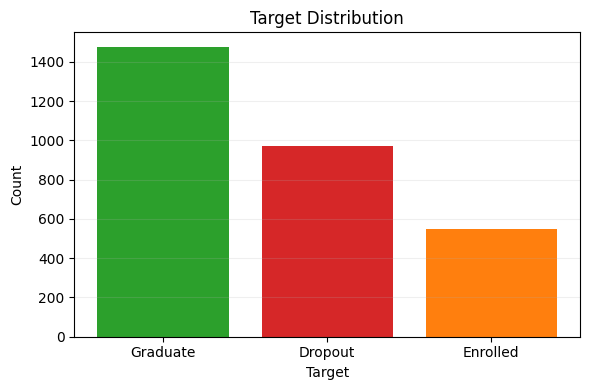

EDA: Correlation heatmap (top numeric features by variance)


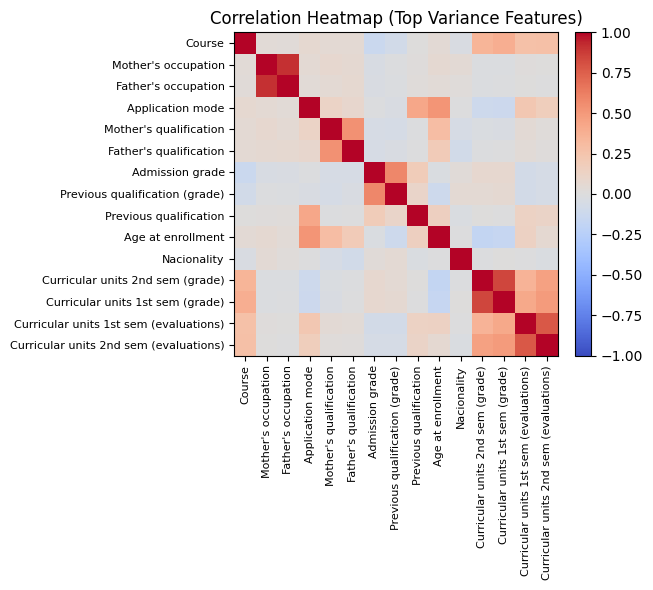


Perplexity search results:
 perplexity  silhouette
         50      0.0248
         40      0.0232
         30      0.0139
Selected perplexity: 50 | Best t-SNE silhouette: 0.0248


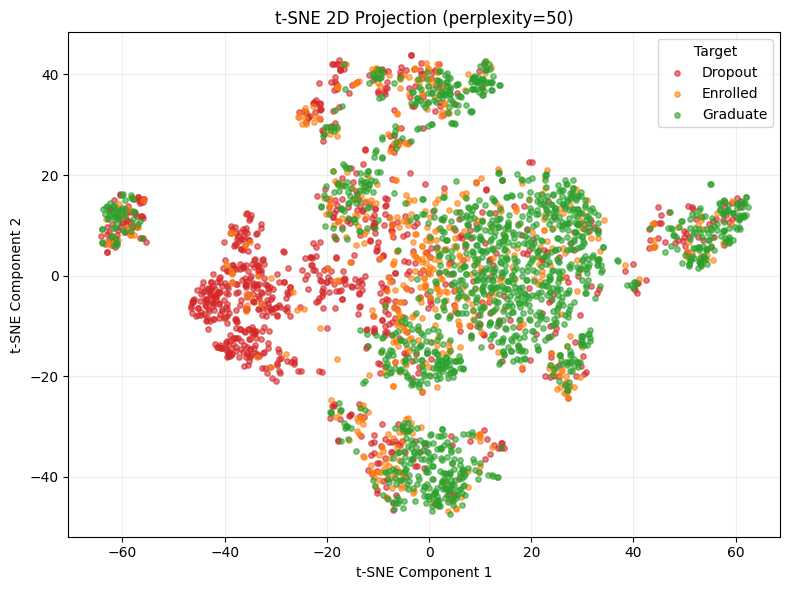

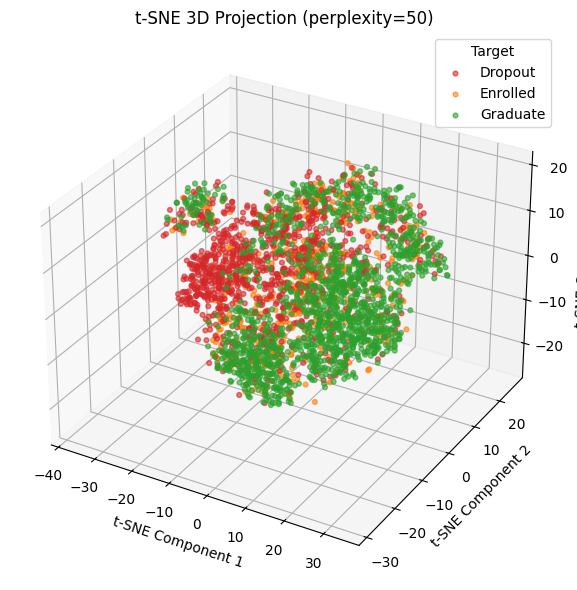

In [16]:
#Part2: Data Visualization (t-SNE core + EDA)

print(f"Current task_mode from Part1: {task_mode}")

#1.Prepare features and labels
X_base = X_processed.copy()
y_label = y.copy() if isinstance(y, pd.Series) else pd.Series(y, name="Target")

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)
class_names = list(le.classes_)

#Optional sampling for speed and clearer scatter plots
max_points = 3000
if len(X_base) > max_points:
    sample_idx = X_base.sample(n=max_points, random_state=42).index
    X_base = X_base.loc[sample_idx]
    y_label = y_label.loc[sample_idx]
    y_encoded = le.transform(y_label)

#Keep feature variants for Part3 compatibility
X_no_scale = X_base.copy()

if "X_standardized" in globals():
    X_selective_scaled = X_standardized.loc[X_base.index].copy()
else:
    #Fallback: standardize only non-binary columns
    X_selective_scaled = X_base.copy()
    num_cols_base = X_selective_scaled.select_dtypes(include=[np.number]).columns.tolist()
    binary_cols_base = [
        c for c in num_cols_base if set(X_selective_scaled[c].dropna().unique()).issubset({0, 1})
    ]
    non_binary_cols_base = [c for c in num_cols_base if c not in binary_cols_base]
    if non_binary_cols_base:
        scaler_fallback = StandardScaler()
        X_selective_scaled[non_binary_cols_base] = scaler_fallback.fit_transform(
            X_selective_scaled[non_binary_cols_base]
        )

best_strategy = "Scale non-binary only (X_standardized)" if "X_standardized" in globals() else "No scaling (X_processed)"
X_scaled_df = X_selective_scaled if best_strategy.startswith("Scale") else X_no_scale
X_scaled = X_scaled_df.values

print(f"Samples used for visualization: {len(X_scaled_df)}")
print(f"Chosen scaling strategy: {best_strategy}")

#2.EDA add-ons: Target distribution + correlation heatmap
print("\nEDA: Target distribution")
target_counts = y_label.value_counts()
plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values, color=["#2ca02c", "#d62728", "#ff7f0e"][:len(target_counts)])
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("EDA: Correlation heatmap (top numeric features by variance)")
num_cols_raw = df_raw.drop(columns=[target_col], errors="ignore").select_dtypes(include=[np.number]).columns.tolist()
if num_cols_raw:
    var_series = df_raw[num_cols_raw].var().sort_values(ascending=False)
    top_k = min(15, len(var_series))
    top_corr_cols = var_series.head(top_k).index
    corr = df_raw[top_corr_cols].corr()

    plt.figure(figsize=(7, 6))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(top_corr_cols)), top_corr_cols, rotation=90, fontsize=8)
    plt.yticks(range(len(top_corr_cols)), top_corr_cols, fontsize=8)
    plt.title("Correlation Heatmap (Top Variance Features)")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for correlation heatmap.")

#3.t-SNE 2D
perplexities = [30, 40, 50]
perplexities = [p for p in perplexities if p < len(X_scaled_df)]
if not perplexities:
    fallback = max(5, min(30, len(X_scaled_df) // 3))
    perplexities = [p for p in [fallback] if p < len(X_scaled_df)]

perp_scores = []
best_perp = None
best_tsne_sil = -np.inf
best_tsne_2d = None

for p in perplexities:
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    emb_2d = tsne.fit_transform(X_scaled)
    sil = silhouette_score(emb_2d, y_encoded)
    perp_scores.append({"perplexity": p, "silhouette": float(sil)})
    if sil > best_tsne_sil:
        best_tsne_sil = sil
        best_perp = p
        best_tsne_2d = emb_2d

perp_df = pd.DataFrame(perp_scores).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("\nPerplexity search results:")
print(perp_df.round(4).to_string(index=False))
print(f"Selected perplexity: {best_perp} | Best t-SNE silhouette: {best_tsne_sil:.4f}")

#Build a dataframe for downstream analysis
tsne_df = pd.DataFrame(best_tsne_2d, columns=["TSNE1", "TSNE2"])
tsne_df["Target"] = y_label.values

#2D scatter plot
color_map = {"Dropout": "#d62728", "Graduate": "#2ca02c", "Enrolled": "#ff7f0e"}
plt.figure(figsize=(8, 6))
for cls in class_names:
    mask = (y_label.values == cls)
    plt.scatter(
        best_tsne_2d[mask, 0],
        best_tsne_2d[mask, 1],
        s=15,
        alpha=0.6,
        label=str(cls),
        color=color_map.get(str(cls), None)
    )
plt.title(f"t-SNE 2D Projection (perplexity={best_perp})")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Target")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#4.3D t-SNE
enable_3d = True
if enable_3d:
    tsne_3d = TSNE(
        n_components=3,
        perplexity=best_perp,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    emb_tsne_3d = tsne_3d.fit_transform(X_scaled)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    for cls in class_names:
        mask = (y_label.values == cls)
        ax.scatter(
            emb_tsne_3d[mask, 0],
            emb_tsne_3d[mask, 1],
            emb_tsne_3d[mask, 2],
            s=12,
            alpha=0.6,
            label=str(cls),
            color=color_map.get(str(cls), None)
        )
    ax.set_title(f"t-SNE 3D Projection (perplexity={best_perp})")
    ax.set_xlabel("t-SNE Component 1")
    ax.set_ylabel("t-SNE Component 2")
    ax.set_zlabel("t-SNE Component 3")
    ax.legend(title="Target")
    plt.tight_layout()
    plt.show()

## Part 3: Clustering Analysis

Part3 Objective: Compare clustering algorithms and select the best result.
Algorithms: K-Means (centroid-based), Agglomerative Ward (hierarchical), DBSCAN (density-based, robust to noise).
DBSCAN setting: run after PCA reduction to 20-50 dimensions.
Feature source: From Part2 best strategy: Scale non-binary only (X_standardized)
Clustering matrix shape: (3000, 262)
DBSCAN PCA dimensions used: [20, 30, 40, 50]
K-Means/Agglomerative feature spaces: ['raw', 'pca=20', 'pca=30']
Scoring mode: interpretability_favored

Part3 Evaluation Table (top 12, optimized weighted score):
           algorithm      config   k  pca_dim  eps  min_samples  n_clusters_found  noise_ratio  valid_internal  silhouette  calinski_harabasz  davies_bouldin  internal_score  external_score  cluster_count_eff  cluster_count_penalty  largest_cluster_ratio  structure_penalty  noise_penalty  missing_internal_penalty  final_score  overall_rank    inertia  ARI_ref  NMI_ref
             K-Means pca=20, k=5 5.0     20.0  NaN 

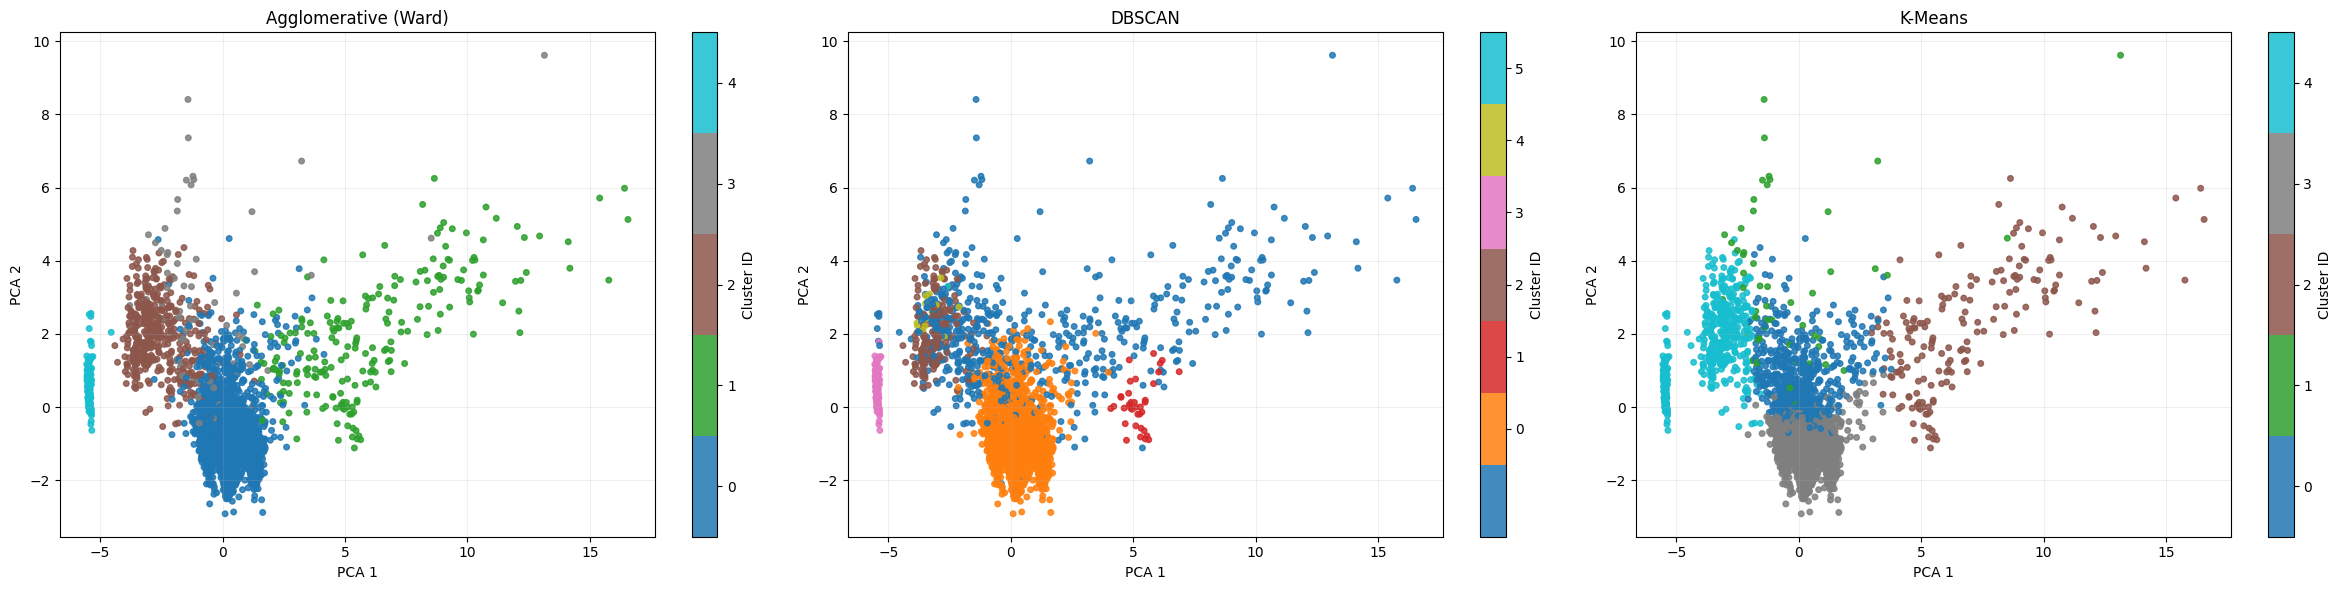

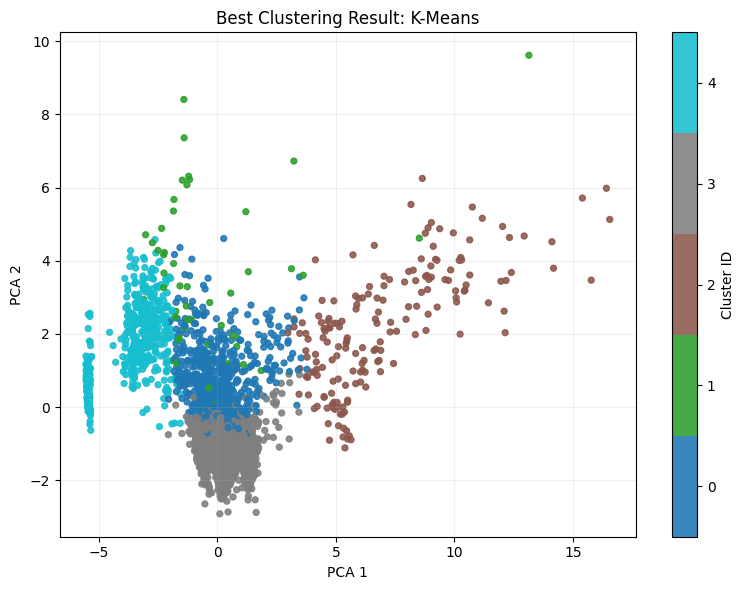


Part3 Conclusion:
Best algorithm: K-Means
Best number of clusters (k): 5
Best feature space for this algorithm: PCA 20 dims
Reason: highest optimized weighted score (internal + external + structure/noise penalties, interpretability-favored).
Interpretation tips:
- Higher Silhouette and CH suggest better separated and compact clusters.
- Lower Davies-Bouldin indicates tighter, more distinct clusters.
- DBSCAN now runs on PCA-reduced space (20-50 dimensions) before clustering.
- DBSCAN can detect noise points (label = -1), useful for outlier-aware clustering.
- ARI/NMI are shown as reference against known target labels (external validation only).


In [17]:
# Part3: Clustering Analysis
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

print("Part3 Objective: Compare clustering algorithms and select the best result.")
print("Algorithms: K-Means (centroid-based), Agglomerative Ward (hierarchical), DBSCAN (density-based, robust to noise).")
print("DBSCAN setting: run after PCA reduction to 20-50 dimensions.")

# 1) Choose feature matrix from previous parts
if "best_strategy" in globals() and "X_no_scale" in globals() and "X_selective_scaled" in globals():
    if best_strategy == "Scale non-binary only (X_standardized)":
        X_cluster_df = X_selective_scaled.copy()
    else:
        X_cluster_df = X_no_scale.copy()
    feature_source = f"From Part2 best strategy: {best_strategy}"
elif "X_standardized" in globals() and "need_standardize" in globals():
    X_cluster_df = X_standardized.copy() if need_standardize else X_processed.copy()
    feature_source = "From Part1 heuristic choice (need_standardize)."
elif "X_standardized" in globals():
    X_cluster_df = X_standardized.copy()
    feature_source = "From Part1 standardized features."
else:
    X_cluster_df = X_processed.copy()
    feature_source = "From Part1 one-hot processed features (no scaling)."

# Keep numeric columns only
X_cluster_df = X_cluster_df.select_dtypes(include=[np.number]).copy()

# Optional reference labels for external validation (not used for model training)
y_ref = None
if "y" in globals():
    y_ref = pd.Series(y).reindex(X_cluster_df.index)
elif "y_label" in globals():
    y_ref = pd.Series(y_label).reindex(X_cluster_df.index)

# Optional sampling for speed
max_cluster_points = 3000
if len(X_cluster_df) > max_cluster_points:
    sample_idx = X_cluster_df.sample(n=max_cluster_points, random_state=42).index
    X_cluster_df = X_cluster_df.loc[sample_idx]
    if y_ref is not None:
        y_ref = y_ref.loc[sample_idx]
    print(f"Sampling applied for clustering: {max_cluster_points} points used.")

X_cluster = X_cluster_df.values
print(f"Feature source: {feature_source}")
print(f"Clustering matrix shape: {X_cluster.shape}")

# 2) Train algorithms and evaluate
k_range = list(range(2, 9))
dbscan_eps_candidates = [3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
dbscan_min_samples_candidates = [3, 4, 5, 10, 15]

# DBSCAN will be tested on PCA-reduced spaces
dbscan_pca_dims_raw = [20, 30, 40, 50]
max_dbscan_dim = min(50, X_cluster.shape[1], X_cluster.shape[0] - 1)
if max_dbscan_dim < 2:
    raise ValueError("Not enough dimensions/samples to run PCA before DBSCAN.")
dbscan_pca_dims = [d for d in dbscan_pca_dims_raw if d <= max_dbscan_dim]
if not dbscan_pca_dims:
    dbscan_pca_dims = [max_dbscan_dim]
print(f"DBSCAN PCA dimensions used: {dbscan_pca_dims}")

# Precompute PCA-transformed feature spaces for DBSCAN
dbscan_spaces = {}
for pca_dim in dbscan_pca_dims:
    pca_dbscan = PCA(n_components=pca_dim, random_state=42)
    dbscan_spaces[pca_dim] = pca_dbscan.fit_transform(X_cluster)

# Strengthen K-Means and Agglomerative by searching in multiple feature spaces
kagg_pca_dims = [d for d in dbscan_pca_dims if d <= 30]
if not kagg_pca_dims:
    kagg_pca_dims = [dbscan_pca_dims[0]]
kagg_spaces = {"raw": X_cluster}
for pca_dim in kagg_pca_dims:
    kagg_spaces[f"pca={pca_dim}"] = dbscan_spaces[pca_dim]
print(f"K-Means/Agglomerative feature spaces: {list(kagg_spaces.keys())}")

results = []
labels_store = {}

def safe_external_scores(y_reference, pred_labels, valid_mask):
    """Compute ARI/NMI safely on filtered points."""
    if y_reference is None:
        return np.nan, np.nan
    valid_y = y_reference.notna().values
    use = valid_mask & valid_y
    if use.sum() <= 1:
        return np.nan, np.nan
    y_valid = y_reference[use].astype(str).values
    pred_valid = pred_labels[use]
    return adjusted_rand_score(y_valid, pred_valid), normalized_mutual_info_score(y_valid, pred_valid)

# K-Means + Agglomerative search across raw/PCA feature spaces
for space_name, X_kagg in kagg_spaces.items():
    pca_dim_val = np.nan if space_name == "raw" else int(space_name.split("=")[1])

    for k in k_range:
        # K-Means
        km = KMeans(n_clusters=k, n_init=50, random_state=42)
        labels_km = km.fit_predict(X_kagg)
        valid_mask_km = np.ones(len(labels_km), dtype=bool)

        sil_km = silhouette_score(X_kagg, labels_km)
        ch_km = calinski_harabasz_score(X_kagg, labels_km)
        db_km = davies_bouldin_score(X_kagg, labels_km)
        ari_km, nmi_km = safe_external_scores(y_ref, labels_km, valid_mask_km)

        config_km = f"k={k}" if space_name == "raw" else f"{space_name}, k={k}"
        results.append({
            "algorithm": "K-Means",
            "config": config_km,
            "k": k,
            "pca_dim": pca_dim_val,
            "eps": np.nan,
            "min_samples": np.nan,
            "n_clusters_found": len(np.unique(labels_km)),
            "noise_ratio": 0.0,
            "silhouette": sil_km,
            "calinski_harabasz": ch_km,
            "davies_bouldin": db_km,
            "inertia": km.inertia_,
            "ARI_ref": ari_km,
            "NMI_ref": nmi_km
        })
        labels_store[("K-Means", config_km)] = labels_km

        # Agglomerative Clustering (Ward linkage)
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels_agg = agg.fit_predict(X_kagg)
        valid_mask_agg = np.ones(len(labels_agg), dtype=bool)

        sil_agg = silhouette_score(X_kagg, labels_agg)
        ch_agg = calinski_harabasz_score(X_kagg, labels_agg)
        db_agg = davies_bouldin_score(X_kagg, labels_agg)
        ari_agg, nmi_agg = safe_external_scores(y_ref, labels_agg, valid_mask_agg)

        config_agg = f"k={k}" if space_name == "raw" else f"{space_name}, k={k}"
        results.append({
            "algorithm": "Agglomerative (Ward)",
            "config": config_agg,
            "k": k,
            "pca_dim": pca_dim_val,
            "eps": np.nan,
            "min_samples": np.nan,
            "n_clusters_found": len(np.unique(labels_agg)),
            "noise_ratio": 0.0,
            "silhouette": sil_agg,
            "calinski_harabasz": ch_agg,
            "davies_bouldin": db_agg,
            "inertia": np.nan,
            "ARI_ref": ari_agg,
            "NMI_ref": nmi_agg
        })
        labels_store[("Agglomerative (Ward)", config_agg)] = labels_agg

# DBSCAN parameter search on PCA-reduced spaces
for pca_dim, X_dbscan in dbscan_spaces.items():
    for eps in dbscan_eps_candidates:
        for min_samples in dbscan_min_samples_candidates:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels_dbscan = dbscan.fit_predict(X_dbscan)

            non_noise_mask = labels_dbscan != -1
            unique_non_noise = np.unique(labels_dbscan[non_noise_mask]) if non_noise_mask.any() else np.array([])
            n_clusters_found = len(unique_non_noise)
            noise_ratio = float((labels_dbscan == -1).mean())

            # Internal metrics need at least 2 clusters on evaluated points
            if n_clusters_found >= 2 and non_noise_mask.sum() > n_clusters_found:
                X_eval = X_dbscan[non_noise_mask]
                y_eval = labels_dbscan[non_noise_mask]
                sil_dbscan = silhouette_score(X_eval, y_eval)
                ch_dbscan = calinski_harabasz_score(X_eval, y_eval)
                db_dbscan = davies_bouldin_score(X_eval, y_eval)
                valid_mask_dbscan = non_noise_mask.copy()
            else:
                sil_dbscan = np.nan
                ch_dbscan = np.nan
                db_dbscan = np.nan
                valid_mask_dbscan = np.zeros(len(labels_dbscan), dtype=bool)

            ari_dbscan, nmi_dbscan = safe_external_scores(y_ref, labels_dbscan, valid_mask_dbscan)

            config_name = f"pca={pca_dim}, eps={eps}, min_samples={min_samples}"
            results.append({
                "algorithm": "DBSCAN",
                "config": config_name,
                "k": np.nan,
                "pca_dim": pca_dim,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters_found": n_clusters_found,
                "noise_ratio": noise_ratio,
                "silhouette": sil_dbscan,
                "calinski_harabasz": ch_dbscan,
                "davies_bouldin": db_dbscan,
                "inertia": np.nan,
                "ARI_ref": ari_dbscan,
                "NMI_ref": nmi_dbscan
            })
            labels_store[("DBSCAN", config_name)] = labels_dbscan

results_df = pd.DataFrame(results)

# 3) Optimized weighted scoring (interpretability-favored)
rank_base = results_df.copy()
rank_base["valid_internal"] = rank_base[["silhouette", "calinski_harabasz", "davies_bouldin"]].notna().all(axis=1)
if not rank_base["valid_internal"].any():
    raise ValueError("No valid clustering result for internal metrics. Please widen DBSCAN parameter range.")

scoring_mode = "interpretability_favored"
print(f"Scoring mode: {scoring_mode}")

def minmax_norm(series):
    s_min = series.min()
    s_max = series.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - s_min) / (s_max - s_min)

# Normalize internal metrics to [0, 1] for fair combination
# For missing internal metrics, use conservative fill so they can still be ranked
sil_for_norm = rank_base["silhouette"].fillna(rank_base.loc[rank_base["valid_internal"], "silhouette"].min())
ch_for_norm = rank_base["calinski_harabasz"].fillna(rank_base.loc[rank_base["valid_internal"], "calinski_harabasz"].min())
db_for_norm = rank_base["davies_bouldin"].fillna(rank_base.loc[rank_base["valid_internal"], "davies_bouldin"].max())
rank_base["sil_norm"] = minmax_norm(sil_for_norm)
rank_base["ch_norm"] = minmax_norm(np.log1p(ch_for_norm))
rank_base["db_norm"] = 1 - minmax_norm(db_for_norm)
rank_base["internal_score"] = (
    0.25 * rank_base["sil_norm"] +
    0.50 * rank_base["ch_norm"] +
    0.25 * rank_base["db_norm"]
)

# Optional external reference score (kept low weight)
has_external = (
    (not rank_base["ARI_ref"].isna().all()) and
    (not rank_base["NMI_ref"].isna().all())
)
if has_external:
    rank_base["ari_norm"] = minmax_norm(rank_base["ARI_ref"].fillna(rank_base["ARI_ref"].min()))
    rank_base["nmi_norm"] = minmax_norm(rank_base["NMI_ref"].fillna(rank_base["NMI_ref"].min()))
    rank_base["external_score"] = 0.5 * rank_base["ari_norm"] + 0.5 * rank_base["nmi_norm"]
else:
    rank_base["external_score"] = 0.0

# Penalize high-noise settings
rank_base["noise_penalty"] = rank_base["noise_ratio"].clip(lower=0.0, upper=1.0)
# Penalize missing internal metrics so those settings participate but rank lower
rank_base["missing_internal_penalty"] = (~rank_base["valid_internal"]).astype(float)

# Structure-aware penalty: penalize too few/too many clusters and highly dominant single cluster
def structure_stats(row):
    labels = labels_store[(row["algorithm"], row["config"])]
    non_noise = labels != -1
    if non_noise.sum() == 0:
        return pd.Series({
            "cluster_count_eff": 0.0,
            "cluster_count_penalty": 1.0,
            "largest_cluster_ratio": 1.0,
            "structure_penalty": 1.0
        })

    unique_labels, counts = np.unique(labels[non_noise], return_counts=True)
    cluster_count_eff = float(len(unique_labels))
    largest_cluster_ratio = float(counts.max() / counts.sum())

    # Prefer moderate cluster counts (3 to 5); penalize both too few and too many clusters
    few_cluster_penalty = max(0.0, (3.0 - cluster_count_eff) / 2.0)
    many_cluster_penalty = max(0.0, (cluster_count_eff - 5.0) / 3.0)
    cluster_count_penalty = min(1.0, few_cluster_penalty + many_cluster_penalty)
    # Penalize when one cluster dominates too much
    dominance_penalty = max(0.0, (largest_cluster_ratio - 0.70) / 0.30)
    structure_penalty = min(1.0, 0.6 * cluster_count_penalty + 0.4 * dominance_penalty)

    return pd.Series({
        "cluster_count_eff": cluster_count_eff,
        "cluster_count_penalty": cluster_count_penalty,
        "largest_cluster_ratio": largest_cluster_ratio,
        "structure_penalty": structure_penalty
    })

rank_base[["cluster_count_eff", "cluster_count_penalty", "largest_cluster_ratio", "structure_penalty"]] = rank_base.apply(structure_stats, axis=1)

if scoring_mode == "interpretability_favored":
    if has_external:
        rank_base["final_score"] = (
            0.50 * rank_base["internal_score"] +
            0.35 * rank_base["external_score"] -
            0.05 * rank_base["noise_penalty"] -
            0.10 * rank_base["structure_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
    else:
        rank_base["final_score"] = (
            0.80 * rank_base["internal_score"] -
            0.08 * rank_base["noise_penalty"] -
            0.12 * rank_base["structure_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
else:
    if has_external:
        rank_base["final_score"] = (
            0.75 * rank_base["internal_score"] +
            0.15 * rank_base["external_score"] -
            0.10 * rank_base["noise_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )
    else:
        rank_base["final_score"] = (
            0.90 * rank_base["internal_score"] -
            0.10 * rank_base["noise_penalty"] -
            0.30 * rank_base["missing_internal_penalty"]
        )

rank_base["overall_rank"] = rank_base["final_score"].rank(ascending=False, method="min")
ranked_df = rank_base.sort_values(
    by=["final_score", "internal_score", "silhouette"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_row = ranked_df.iloc[0]
best_algo = best_row["algorithm"]
best_config = best_row["config"]
best_k = int(best_row["k"]) if pd.notna(best_row["k"]) else None
best_labels = labels_store[(best_algo, best_config)]

print("\nPart3 Evaluation Table (top 12, optimized weighted score):")
display_cols = [
    "algorithm", "config", "k", "pca_dim", "eps", "min_samples", "n_clusters_found", "noise_ratio",
    "valid_internal", "silhouette", "calinski_harabasz", "davies_bouldin", "internal_score", "external_score",
    "cluster_count_eff", "cluster_count_penalty", "largest_cluster_ratio", "structure_penalty", "noise_penalty",
    "missing_internal_penalty", "final_score", "overall_rank", "inertia", "ARI_ref", "NMI_ref"
]
print(ranked_df[display_cols].head(12).round(4).to_string(index=False))

invalid_dbscan_count = (
    results_df[(results_df["algorithm"] == "DBSCAN") & results_df["silhouette"].isna()]
    .shape[0]
 )
if invalid_dbscan_count > 0:
    print(f"\nNote: {invalid_dbscan_count} DBSCAN settings lacked full internal metrics but were included with missing-metric penalty.")

# 4) Visualize clusters in 2D using PCA projection
pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_cluster)

best_per_algo = (
    ranked_df.sort_values(["algorithm", "final_score", "silhouette"], ascending=[True, False, False])
    .groupby("algorithm", as_index=False)
    .first()
)

algo_order = best_per_algo["algorithm"].tolist()
fig, axes = plt.subplots(1, len(algo_order), figsize=(8 * len(algo_order), 6))
if len(algo_order) == 1:
    axes = [axes]

def plot_with_discrete_cluster_ids(ax_obj, x_2d, labels, point_size=16, alpha=0.85):
    unique_ids = np.sort(np.unique(labels))
    id_to_pos = {cid: i for i, cid in enumerate(unique_ids)}
    mapped = np.array([id_to_pos[cid] for cid in labels])

    cmap = plt.get_cmap("tab10", len(unique_ids))
    sc_local = ax_obj.scatter(
        x_2d[:, 0], x_2d[:, 1],
        c=mapped, cmap=cmap, s=point_size, alpha=alpha,
        vmin=-0.5, vmax=len(unique_ids) - 0.5
    )

    # Show only real cluster IDs on colorbar; DBSCAN noise label -1 is excluded
    display_ids = [cid for cid in unique_ids if cid != -1]
    if not display_ids:
        display_ids = list(unique_ids)

    display_ticks = [id_to_pos[cid] for cid in display_ids]
    cbar = plt.colorbar(sc_local, ax=ax_obj, ticks=display_ticks)
    cbar.set_ticklabels([str(int(cid)) for cid in display_ids])
    cbar.set_label("Cluster ID")

    return sc_local

for ax, algo_name in zip(axes, algo_order):
    row_algo = best_per_algo[best_per_algo["algorithm"] == algo_name].iloc[0]
    config_algo = row_algo["config"]
    labels_algo = labels_store[(algo_name, config_algo)]

    plot_with_discrete_cluster_ids(ax, X_vis, labels_algo, point_size=16, alpha=0.85)

    ax.set_title(f"{algo_name}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Best model visualization
fig_best, ax_best = plt.subplots(figsize=(8, 6))
plot_with_discrete_cluster_ids(ax_best, X_vis, best_labels, point_size=18, alpha=0.88)

ax_best.set_title(f"Best Clustering Result: {best_algo}")
ax_best.set_xlabel("PCA 1")
ax_best.set_ylabel("PCA 2")
ax_best.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 5) Final conclusion
print("\nPart3 Conclusion:")
print(f"Best algorithm: {best_algo}")
if best_algo == "DBSCAN":
    print(f"Best DBSCAN setting: {best_config}")
    print(f"Clusters found (excluding noise): {int(best_row['n_clusters_found'])}")
    print(f"Noise ratio: {best_row['noise_ratio']:.2%}")
else:
    print(f"Best number of clusters (k): {best_k}")
    if pd.notna(best_row["pca_dim"]):
        print(f"Best feature space for this algorithm: PCA {int(best_row['pca_dim'])} dims")
    else:
        print("Best feature space for this algorithm: raw features")
print("Reason: highest optimized weighted score (internal + external + structure/noise penalties, interpretability-favored).")
print("Interpretation tips:")
print("- Higher Silhouette and CH suggest better separated and compact clusters.")
print("- Lower Davies-Bouldin indicates tighter, more distinct clusters.")
print("- DBSCAN now runs on PCA-reduced space (20-50 dimensions) before clustering.")
print("- DBSCAN can detect noise points (label = -1), useful for outlier-aware clustering.")
if not ranked_df["ARI_ref"].isna().all():
    print("- ARI/NMI are shown as reference against known target labels (external validation only).")

In [18]:
# Quick summary of ranking result
summary_cols = [
    "algorithm", "config", "k", "pca_dim", "n_clusters_found", "noise_ratio",
    "valid_internal", "silhouette", "calinski_harabasz", "davies_bouldin",
    "internal_score", "external_score", "structure_penalty",
    "missing_internal_penalty", "final_score", "overall_rank", "ARI_ref", "NMI_ref"
]

print("Top 5 by final_score:")
print(ranked_df[summary_cols].head(5).round(4).to_string(index=False))

print("\nBest row detail:")
best_detail = best_row[summary_cols].copy()
for c in best_detail.index:
    if isinstance(best_detail[c], (int, float, np.floating, np.integer)) and pd.notna(best_detail[c]):
        best_detail[c] = round(float(best_detail[c]), 4)
print(best_detail.to_string())

Top 5 by final_score:
           algorithm      config   k  pca_dim  n_clusters_found  noise_ratio  valid_internal  silhouette  calinski_harabasz  davies_bouldin  internal_score  external_score  structure_penalty  missing_internal_penalty  final_score  overall_rank  ARI_ref  NMI_ref
             K-Means pca=20, k=5 5.0     20.0                 5          0.0            True      0.1650           506.1999          1.9429          0.5989          0.9811             0.0000                       0.0       0.6429           1.0   0.2319   0.1729
             K-Means pca=20, k=4 4.0     20.0                 4          0.0            True      0.1850           580.2308          2.1248          0.5999          0.9750             0.0000                       0.0       0.6412           2.0   0.2272   0.1741
             K-Means pca=30, k=4 4.0     30.0                 4          0.0            True      0.1670           512.6250          2.2808          0.5615          0.9726             0.0000  

## Part 4: Prediction: Model Training & Testing

Current task_mode: full

Target classes: ['Dropout', 'Enrolled', 'Graduate']
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Target distribution (%):
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95

Split ratio: 70% train / 30% test
Training set: 3096 samples
Test set:     1328 samples

Decision Tree (max_depth=5)
        Accuracy  Precision  Recall      F1  Train-Test F1 Gap
Subset                                                        
Train     0.7658     0.7433  0.6538  0.6680                NaN
Test      0.7417     0.6930  0.6283  0.6388             0.0292
All       0.7586     0.7270  0.6462  0.6592                NaN

Classification report — Test set:
              precision    recall  f1-score   support

     Dropout       0.85      0.66      0.74       427
    Enrolled       0.50      0.26      0.34       238
    Graduate       0.74      0.97      0.84       663

    accuracy                           0.74      1328
   macro avg      

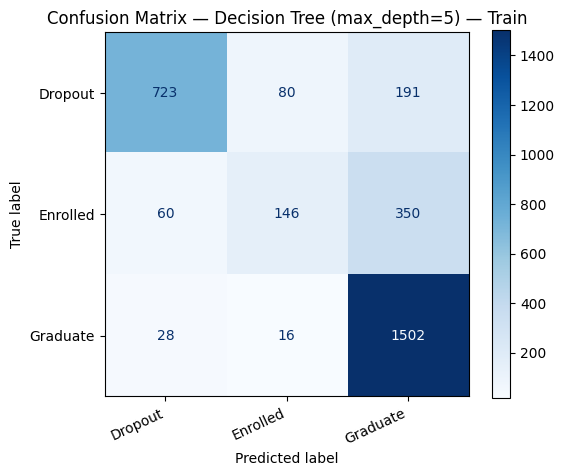

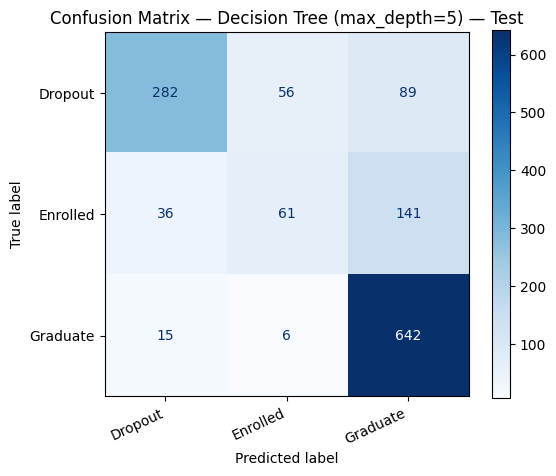

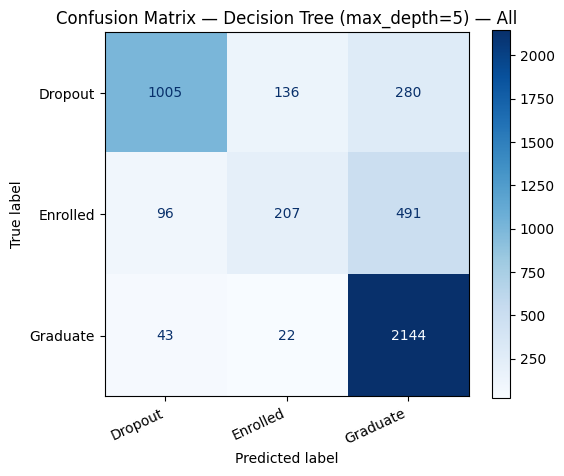


Logistic Regression
        Accuracy  Precision  Recall      F1  Train-Test F1 Gap
Subset                                                        
Train     0.8081     0.7778  0.7332  0.7475                NaN
Test      0.7764     0.7241  0.6987  0.7072             0.0404
All       0.7986     0.7610  0.7228  0.7352                NaN

Classification report — Test set:
              precision    recall  f1-score   support

     Dropout       0.80      0.77      0.79       427
    Enrolled       0.55      0.42      0.47       238
    Graduate       0.81      0.91      0.86       663

    accuracy                           0.78      1328
   macro avg       0.72      0.70      0.71      1328
weighted avg       0.76      0.78      0.77      1328



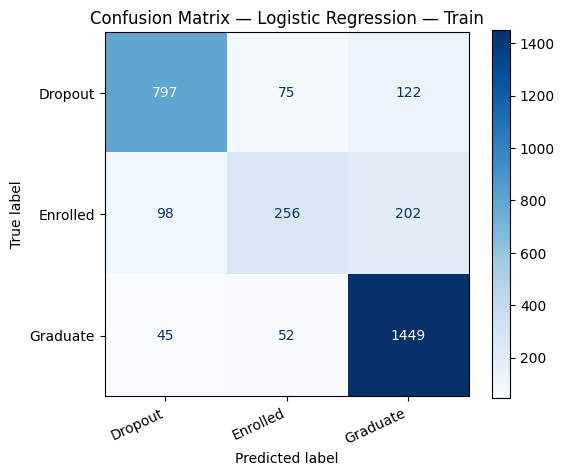

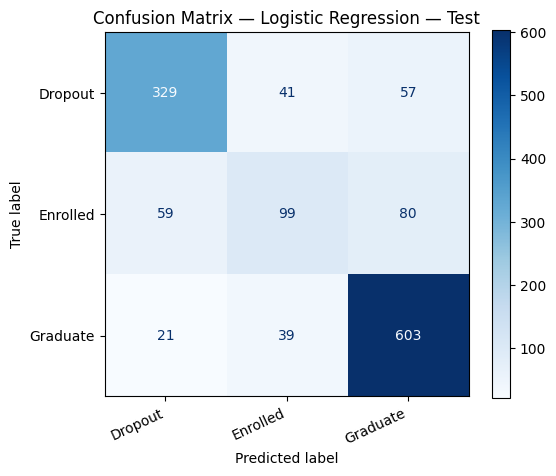

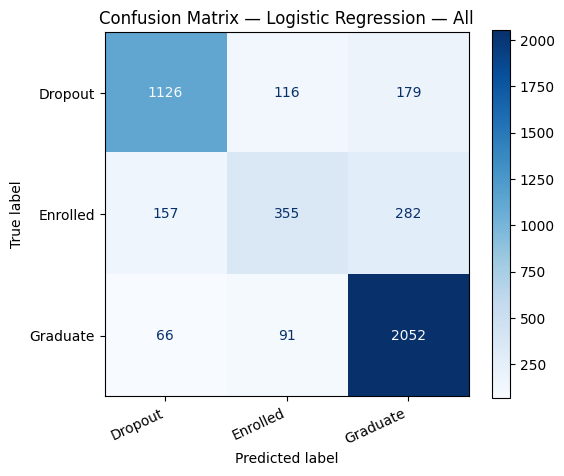


Model Comparison — Test Set
                             Test Accuracy  Test Precision  Test Recall  Test F1  Train-Test F1 Gap
Model                                                                                              
Logistic Regression                 0.7764          0.7241       0.6987   0.7072             0.0404
Decision Tree (max_depth=5)         0.7417          0.6930       0.6283   0.6388             0.0292

Best model by Test Macro-F1: Logistic Regression


In [19]:
# Part 4: Prediction — Model Training & Testing (Optimized Version)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── 0. Basic checks ──────────────────────────────────────────────────
required_vars = ["X_processed", "X_standardized", "y"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Missing variables from Part 1: {missing_vars}. "
        "Please run Part 1 before Part 4."
    )

if "task_mode" in globals():
    print(f"Current task_mode: {task_mode}")
    if task_mode == "full":
        print(
            "WARNING: full mode keeps semester-performance features. "
            "Do not describe this result as early-warning prediction unless Part 1 is rerun with task_mode='early'."
        )

# ── 1. Prepare target label ──────────────────────────────────────────
# Target is a three-class label: Dropout / Enrolled / Graduate.
y_series = pd.Series(y, name="Target").reset_index(drop=True)

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y_series)
class_names = list(le_target.classes_)

print("\nTarget classes:", class_names)
print("Target distribution:")
print(y_series.value_counts().to_string())
print("Target distribution (%):")
print((y_series.value_counts(normalize=True) * 100).round(2).to_string())

# ── 2. Train/test split ──────────────────────────────────────────────
# Use the same split for raw one-hot features and standardized features.
RANDOM_STATE = 42
TEST_SIZE = 0.30

X_train_s, X_test_s, X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_standardized,
    X_processed,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"\nSplit ratio: {(1 - TEST_SIZE):.0%} train / {TEST_SIZE:.0%} test")
print(f"Training set: {X_train_s.shape[0]} samples")
print(f"Test set:     {X_test_s.shape[0]} samples")

# ── 3. Train baseline classifiers ────────────────────────────────────
# Decision Tree uses unstandardized one-hot features.
# Logistic Regression uses standardized features because it is scale-sensitive.
models = {}

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)
dt.fit(X_train_raw, y_train)
models["Decision Tree (max_depth=5)"] = (dt, X_train_raw, X_test_raw)

lr = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_s, y_train)
models["Logistic Regression"] = (lr, X_train_s, X_test_s)

# ── 4. Helper functions ──────────────────────────────────────────────
def combine_train_test(X_train, X_test):
    """Combine train and test matrices while preserving DataFrame columns if possible."""
    if isinstance(X_train, pd.DataFrame) and isinstance(X_test, pd.DataFrame):
        return pd.concat([X_train, X_test], axis=0)
    return np.vstack([X_train, X_test])


def compute_metrics(y_true, y_pred):
    """Return main multi-class metrics. Macro average treats all classes equally."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def plot_confusion_matrix(y_true, y_pred, model_name, subset_name, class_names):
    """Plot one confusion matrix with count labels."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
    ax.set_title(f"Confusion Matrix — {model_name} — {subset_name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, class_names, plot_subsets=("Train", "Test", "All")):
    """Evaluate one model on train, test, and full dataset."""
    X_all = combine_train_test(X_train, X_test)
    y_all = np.concatenate([y_train, y_test])

    predictions = {
        "Train": (y_train, model.predict(X_train)),
        "Test":  (y_test,  model.predict(X_test)),
        "All":   (y_all,   model.predict(X_all)),
    }

    rows = []
    for subset_name, (y_true, y_pred) in predictions.items():
        row = compute_metrics(y_true, y_pred)
        row["Subset"] = subset_name
        rows.append(row)

    results_df = pd.DataFrame(rows).set_index("Subset")
    results_df["Train-Test F1 Gap"] = np.nan
    results_df.loc["Test", "Train-Test F1 Gap"] = results_df.loc["Train", "F1"] - results_df.loc["Test", "F1"]

    print(f"\n{'='*70}")
    print(f"{model_name}")
    print(f"{'='*70}")
    print(results_df.round(4).to_string())

    print("\nClassification report — Test set:")
    print(classification_report(
        y_test,
        predictions["Test"][1],
        target_names=class_names,
        zero_division=0
    ))

    # Plot confusion matrices for train/test/all to match Part 4 requirement.
    for subset_name in plot_subsets:
        y_true, y_pred = predictions[subset_name]
        plot_confusion_matrix(y_true, y_pred, model_name, subset_name, class_names)

    return results_df

# ── 5. Evaluate all models ───────────────────────────────────────────
all_results = {}
for model_name, (model, X_tr, X_te) in models.items():
    all_results[model_name] = evaluate_model(
        model=model,
        X_train=X_tr,
        y_train=y_train,
        X_test=X_te,
        y_test=y_test,
        model_name=model_name,
        class_names=class_names,
        plot_subsets=("Train", "Test", "All")
    )

# ── 6. Model comparison table ────────────────────────────────────────
comparison_rows = []
for model_name, result_df in all_results.items():
    test_row = result_df.loc["Test"].copy()
    comparison_rows.append({
        "Model": model_name,
        "Test Accuracy": test_row["Accuracy"],
        "Test Precision": test_row["Precision"],
        "Test Recall": test_row["Recall"],
        "Test F1": test_row["F1"],
        "Train-Test F1 Gap": test_row["Train-Test F1 Gap"],
    })

comp_df = pd.DataFrame(comparison_rows).set_index("Model").sort_values("Test F1", ascending=False)

print(f"\n{'='*70}")
print("Model Comparison — Test Set")
print(f"{'='*70}")
print(comp_df.round(4).to_string())

best_model_name = comp_df.index[0]
print(f"\nBest model by Test Macro-F1: {best_model_name}")


## Part 5: Model Evaluation & Improvement

Part 5 Objective: Deep evaluation, ROC/AUC, and model improvement.
Baseline models from Part 4: ['Decision Tree (max_depth=5)', 'Logistic Regression']

  1. ROC Curves & AUC (One-vs-Rest)


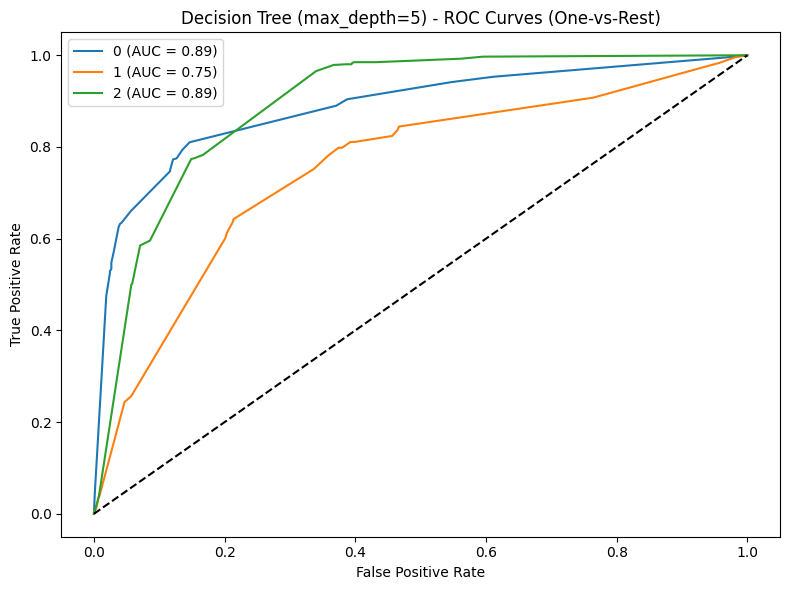

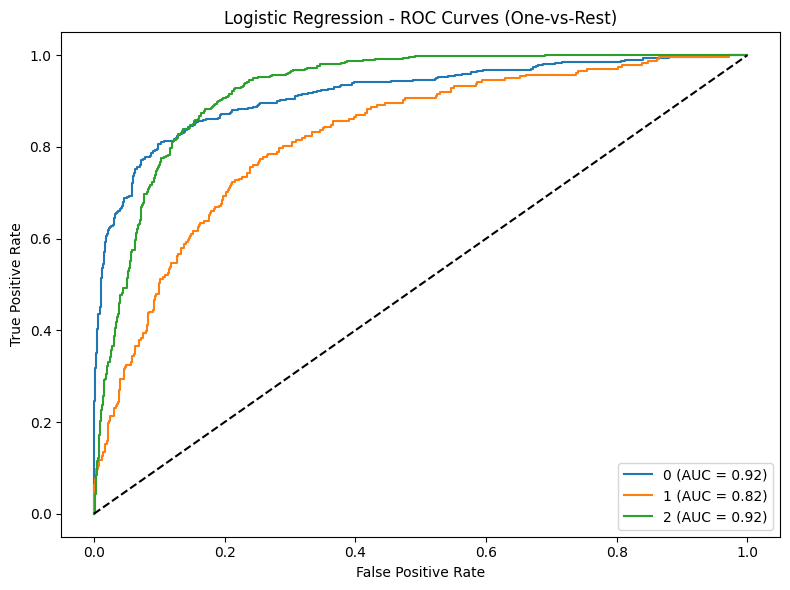


  1.5 Precision-Recall Curves


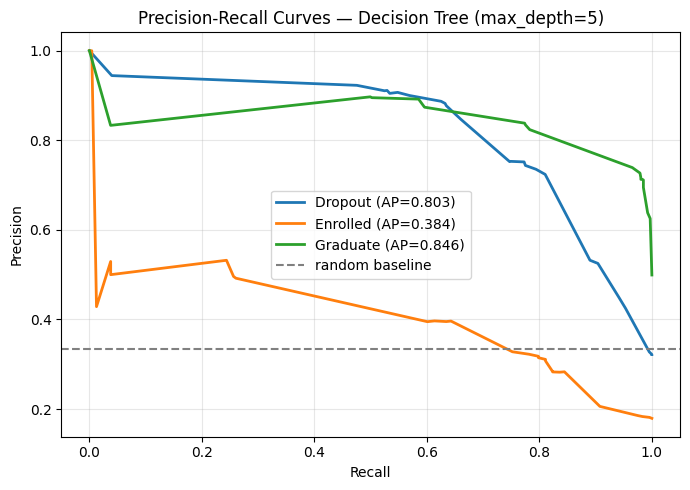

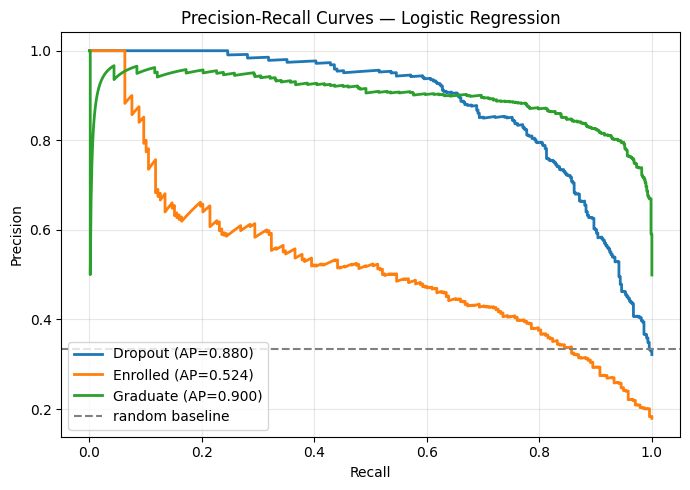


  2. Cross-Validation (5-fold, stratified)

Mean scores across 5 folds:
Metric               accuracy      f1  precision  recall
Model                                                   
Decision Tree          0.7374  0.6334     0.6901  0.6257
Logistic Regression    0.7733  0.6985     0.7243  0.6885

Standard deviation:
Metric               accuracy      f1  precision  recall
Model                                                   
Decision Tree          0.0144  0.0050     0.0132  0.0088
Logistic Regression    0.0141  0.0145     0.0194  0.0138

  3. Learning Curves (bias-variance diagnosis)

Decision Tree:


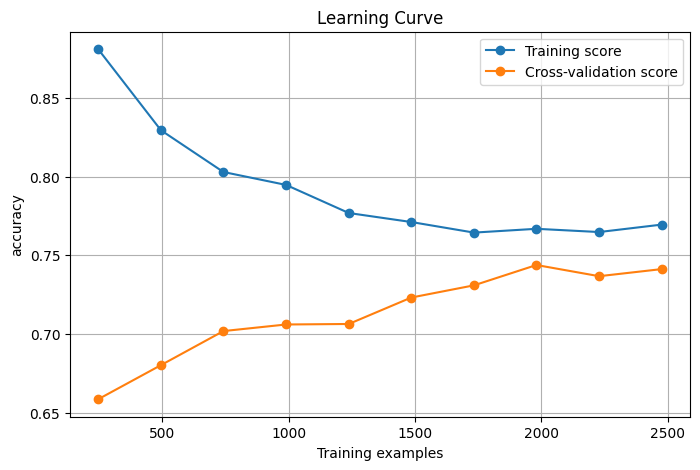


Logistic Regression:


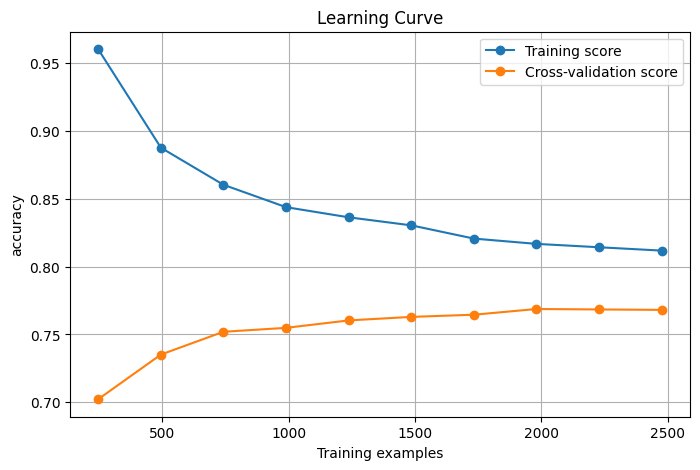


  4. Hyperparameter Tuning (GridSearchCV)

>>> Decision Tree
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV f1_macro: 0.6668

>>> Logistic Regression
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'C': 0.1}
Best CV f1_macro: 0.6925

  4.5 L1 vs L2 Regularization — Logistic Regression
         CV F1 Mean  CV F1 Std  Non-zero coefs  Total coefs
Penalty                                                    
L1           0.6993     0.0148             194          786
L2           0.6985     0.0145             744          786

L1 (Lasso) can zero out coefficients → automatic feature selection.
L2 (Ridge) shrinks all coefficients but rarely zeros them → better when all features matter.

  5. Tuned Models — Final Evaluation

Decision Tree (tuned, depth=8) Evaluation:
         Accuracy  Precision  Recall      F1
Subset                                     
Train     0.81

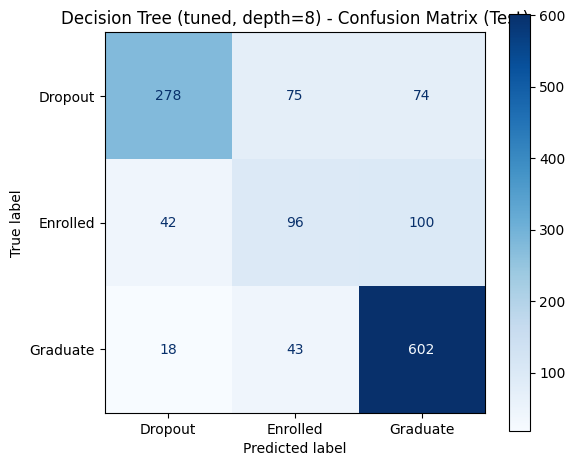

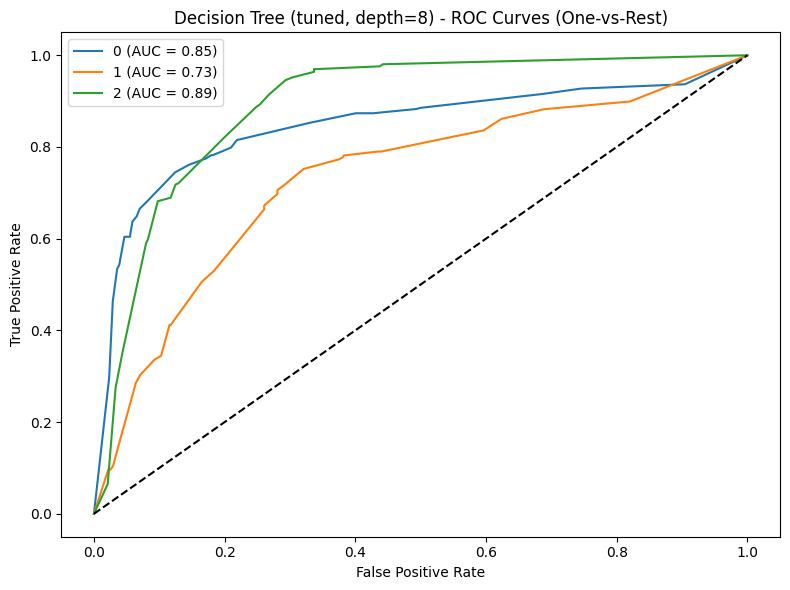

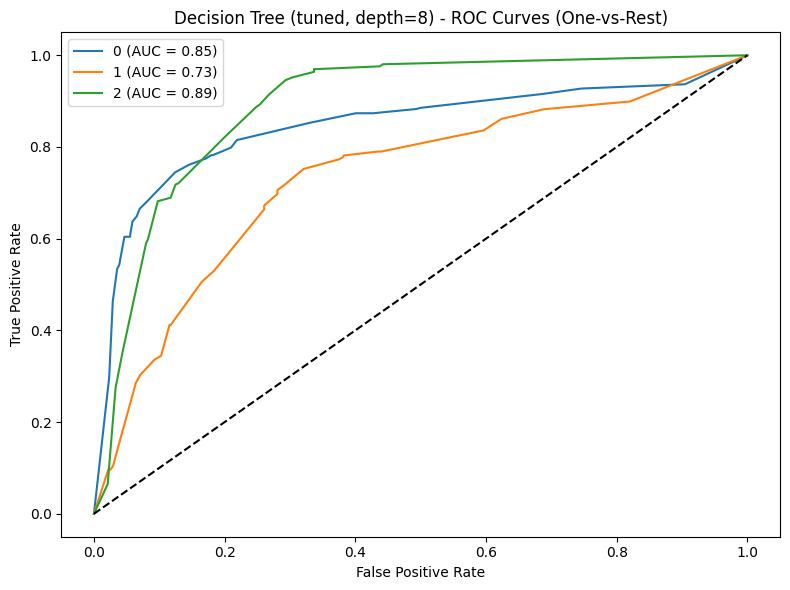


Logistic Regression (tuned, C=0.1) Evaluation:
         Accuracy  Precision  Recall      F1
Subset                                     
Train     0.7988     0.7665  0.7147  0.7292
Test      0.7809     0.7356  0.6937  0.7052
All       0.7934     0.7571  0.7084  0.7220

Classification Report (Test):
              precision    recall  f1-score   support

     Dropout       0.81      0.76      0.79       427
    Enrolled       0.59      0.38      0.46       238
    Graduate       0.80      0.94      0.86       663

    accuracy                           0.78      1328
   macro avg       0.74      0.69      0.71      1328
weighted avg       0.77      0.78      0.77      1328



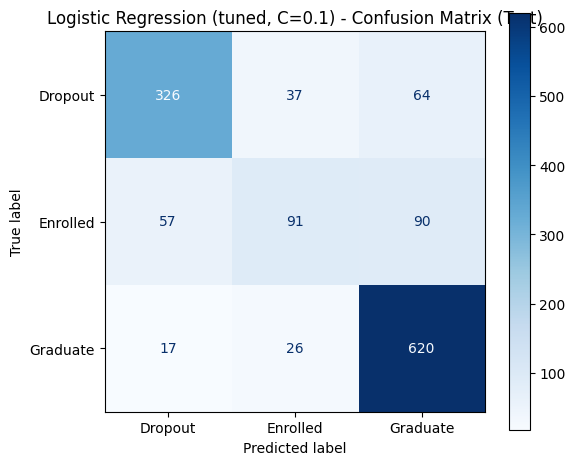

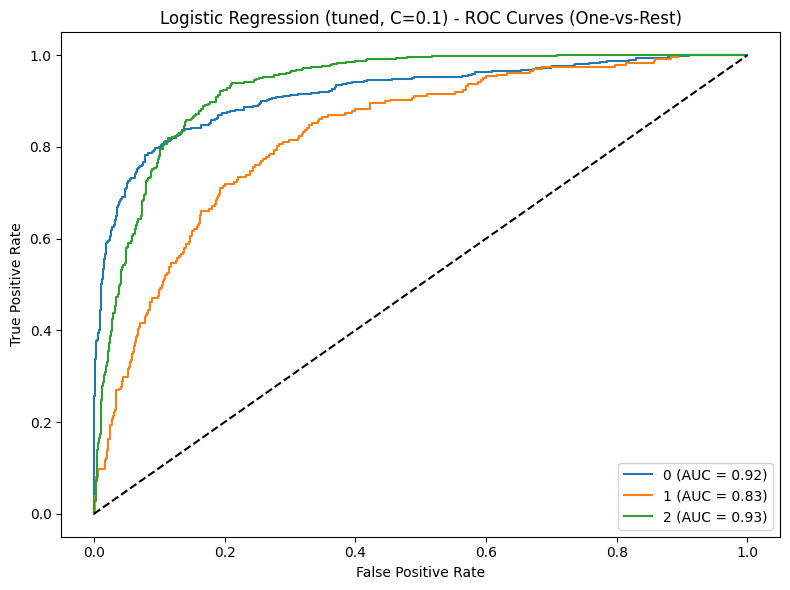

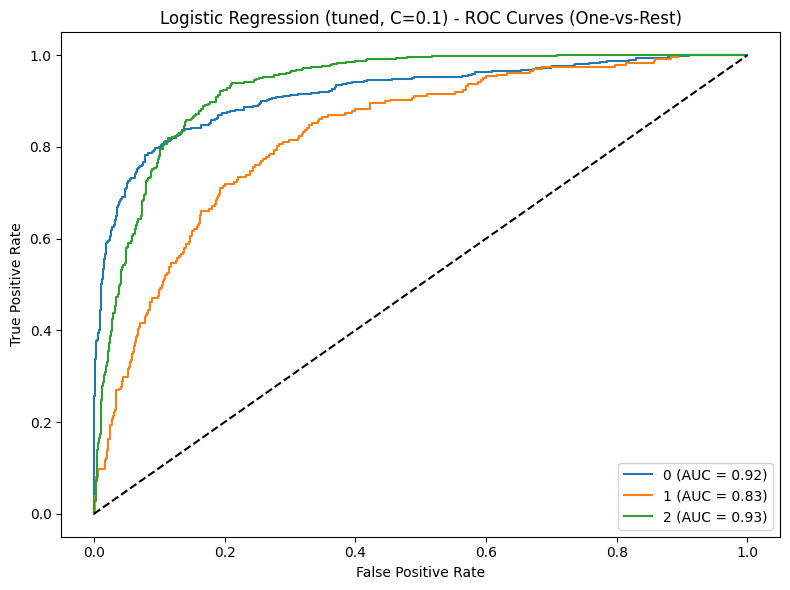


  6. Baseline vs Tuned — Test Set Comparison
                                             Accuracy  Precision  Recall      F1
Model                                                                           
Decision Tree (max_depth=5)  (baseline)        0.7417     0.6930  0.6283  0.6388
Logistic Regression  (baseline)                0.7764     0.7241  0.6987  0.7072
Decision Tree (tuned, depth=8)  (tuned)        0.7349     0.6823  0.6541  0.6628
Logistic Regression (tuned, C=0.1)  (tuned)    0.7809     0.7356  0.6937  0.7052

Improvement (tuned - baseline):
  Decision Tree :  Delta_F1 = +0.0239  |  Delta_Accuracy = -0.0068
  Logistic Regression :  Delta_F1 = -0.0020  |  Delta_Accuracy = +0.0045

  7. Feature Importance — Top 15


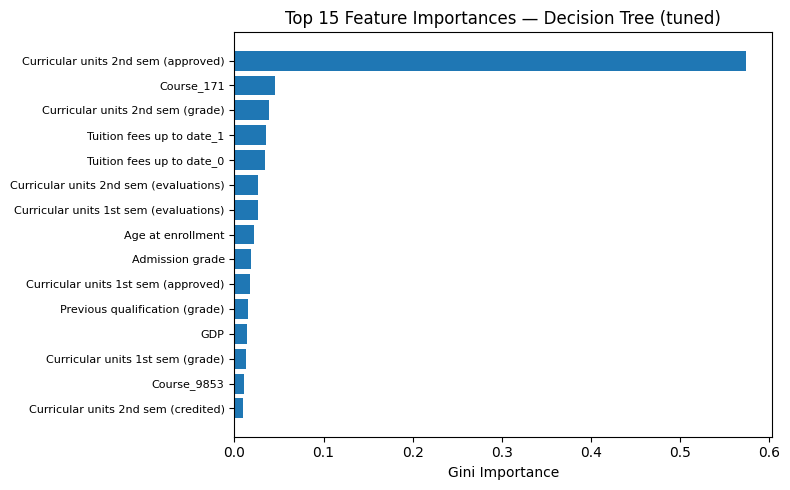

Top 15 features by importance:
   1. Curricular units 2nd sem (approved)                 0.5741
   2. Course_171                                          0.0452
   3. Curricular units 2nd sem (grade)                    0.0386
   4. Tuition fees up to date_1                           0.0359
   5. Tuition fees up to date_0                           0.0347
   6. Curricular units 2nd sem (evaluations)              0.0261
   7. Curricular units 1st sem (evaluations)              0.0260
   8. Age at enrollment                                   0.0226
   9. Admission grade                                     0.0182
  10. Curricular units 1st sem (approved)                 0.0175
  11. Previous qualification (grade)                      0.0148
  12. GDP                                                 0.0142
  13. Curricular units 1st sem (grade)                    0.0128
  14. Course_9853                                         0.0110
  15. Curricular units 2nd sem (credited)                 0

In [20]:
# Part 5: Model Evaluation & Improvement

import sys
sys.path.insert(0, "05_evaluation")
from evaluation import evaluate_model, plot_roc_curves, plot_learning_curve
from model_improvement import hyperparameter_tuning, feature_selection_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

print("Part 5 Objective: Deep evaluation, ROC/AUC, and model improvement.")
print(f"Baseline models from Part 4: {list(models.keys())}")

# ── 1. ROC Curves & AUC ──────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  1. ROC Curves & AUC (One-vs-Rest)")
print(f"{'='*55}")

for name, (model, X_tr, X_te) in models.items():
    if hasattr(model, "predict_proba"):
        plot_roc_curves(model, X_te, y_test, name)
    else:
        print(f"  {name}: no predict_proba — skipping ROC.")

# ── 1.5 Precision-Recall Curves ──────────────────────────────────────
# PR curves are more informative than ROC for imbalanced data (Enrolled=18%)
print(f"\n{'='*55}")
print(f"  1.5 Precision-Recall Curves")
print(f"{'='*55}")

for name, (model, X_tr, X_te) in models.items():
    if not hasattr(model, "predict_proba"):
        continue
    y_score = model.predict_proba(X_te)
    classes_uniq = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes_uniq)

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, cls in enumerate(le_target.classes_):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
        ax.plot(rec, prec, lw=2, label=f"{cls} (AP={ap:.3f})")

    # Baseline = random classifier
    baseline = y_test_bin.sum(axis=0) / len(y_test)
    ax.axhline(baseline.mean(), ls="--", color="grey", label=f"random baseline")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curves — {name}")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# ── 2. Cross-Validation ──────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  2. Cross-Validation (5-fold, stratified)")
print(f"{'='*55}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Re-create fresh classifiers for unbiased CV
cv_classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000),
}
cv_features = {
    "Decision Tree": X_train_raw,
    "Logistic Regression": X_train_s,
}

cv_summary = []
for name, clf in cv_classifiers.items():
    X_cv = cv_features[name]
    for metric in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]:
        scores = cross_val_score(clf, X_cv, y_train, cv=cv, scoring=metric)
        short = metric.replace("_macro", "")
        cv_summary.append({
            "Model": name, "Metric": short,
            "Mean": scores.mean(), "Std": scores.std()
        })

cv_df = pd.DataFrame(cv_summary)
print("\nMean scores across 5 folds:")
print(cv_df.pivot(index="Model", columns="Metric", values="Mean").round(4).to_string())
print("\nStandard deviation:")
print(cv_df.pivot(index="Model", columns="Metric", values="Std").round(4).to_string())

# ── 3. Learning Curves ───────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  3. Learning Curves (bias-variance diagnosis)")
print(f"{'='*55}")

for name, clf in cv_classifiers.items():
    X_lc = cv_features[name]
    print(f"\n{name}:")
    plot_learning_curve(clf, X_lc, y_train, cv=5, scoring="accuracy")
    plt.show()

# ── 4. Hyperparameter Tuning ─────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  4. Hyperparameter Tuning (GridSearchCV)")
print(f"{'='*55}")

# Decision Tree
print("\n>>> Decision Tree")
dt_param_grid = {
    "max_depth": [3, 5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}
dt_tuned, dt_best = hyperparameter_tuning(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, X_train_raw, y_train, cv=5, scoring="f1_macro"
)

# Logistic Regression
print("\n>>> Logistic Regression")
lr_param_grid = {
    "C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
}
lr_tuned, lr_best = hyperparameter_tuning(
    LogisticRegression(random_state=42, max_iter=5000),
    lr_param_grid, X_train_s, y_train, cv=5, scoring="f1_macro"
)

# ── 4.5 L1 vs L2 Regularization ──────────────────────────────────────
# LA06 / L06 emphasize comparing L1 (Lasso) and L2 (Ridge) penalties
print(f"\n{'='*55}")
print(f"  4.5 L1 vs L2 Regularization — Logistic Regression")
print(f"{'='*55}")

l1_results = []
for penalty in ["l1", "l2"]:
    solver = "saga" if penalty == "l1" else "lbfgs"
    lr_reg = LogisticRegression(
        penalty=penalty, solver=solver, random_state=42, max_iter=5000, C=1.0
    )
    scores = cross_val_score(lr_reg, X_train_s, y_train, cv=cv, scoring="f1_macro")
    # Also check sparsity for L1
    lr_reg.fit(X_train_s, y_train)
    n_nonzero = int((np.abs(lr_reg.coef_) > 1e-5).sum())
    l1_results.append({
        "Penalty": penalty.upper(),
        "CV F1 Mean": scores.mean(),
        "CV F1 Std":  scores.std(),
        "Non-zero coefs": n_nonzero,
        "Total coefs": lr_reg.coef_.size,
    })

l1_df = pd.DataFrame(l1_results).set_index("Penalty")
print(l1_df.round(4).to_string())
print("\nL1 (Lasso) can zero out coefficients → automatic feature selection.")
print("L2 (Ridge) shrinks all coefficients but rarely zeros them → better when all features matter.")

# ── 5. Evaluate Tuned Models ─────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  5. Tuned Models — Final Evaluation")
print(f"{'='*55}")

tuned_models = {
    f"Decision Tree (tuned, depth={dt_best.get('max_depth', '?')})": (dt_tuned, X_train_raw, X_test_raw),
    f"Logistic Regression (tuned, C={lr_best.get('C', '?')})": (lr_tuned, X_train_s, X_test_s),
}

tuned_results = {}
for name, (model, X_tr, X_te) in tuned_models.items():
    tuned_results[name] = evaluate_model(
        model, X_tr, y_train, X_te, y_test, name, le_target.classes_
    )
    # ROC for tuned models
    if hasattr(model, "predict_proba"):
        plot_roc_curves(model, X_te, y_test, name)

# ── 6. Before vs After ───────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  6. Baseline vs Tuned — Test Set Comparison")
print(f"{'='*55}")

final_comparison = []
for name, res_df in all_results.items():
    final_comparison.append({
        "Model": f"{name}  (baseline)",
        "Accuracy": res_df.loc["Test", "Accuracy"],
        "Precision": res_df.loc["Test", "Precision"],
        "Recall": res_df.loc["Test", "Recall"],
        "F1": res_df.loc["Test", "F1"],
    })
for name, res_df in tuned_results.items():
    final_comparison.append({
        "Model": f"{name}  (tuned)",
        "Accuracy": res_df.loc["Test", "Accuracy"],
        "Precision": res_df.loc["Test", "Precision"],
        "Recall": res_df.loc["Test", "Recall"],
        "F1": res_df.loc["Test", "F1"],
    })

final_df = pd.DataFrame(final_comparison).set_index("Model")
print(final_df.round(4).to_string())

# Highlight improvement
print("\nImprovement (tuned - baseline):")
dt_baseline = final_df.loc[final_df.index.str.contains("Decision Tree.*baseline")].iloc[0]
dt_best_row = final_df.loc[final_df.index.str.contains("Decision Tree.*tuned")].iloc[0]
lr_baseline = final_df.loc[final_df.index.str.contains("Logistic Regression.*baseline")].iloc[0]
lr_best_row = final_df.loc[final_df.index.str.contains("Logistic Regression.*tuned")].iloc[0]

for model_name, base, tuned in [
    ("Decision Tree", dt_baseline, dt_best_row),
    ("Logistic Regression", lr_baseline, lr_best_row),
]:
    delta_f1 = tuned["F1"] - base["F1"]
    delta_acc = tuned["Accuracy"] - base["Accuracy"]
    print(f"  {model_name} :  Delta_F1 = {delta_f1:+.4f}  |  Delta_Accuracy = {delta_acc:+.4f}")

# ── 7. Feature Importance (Decision Tree) ────────────────────────────
print(f"\n{'='*55}")
print(f"  7. Feature Importance — Top 15")
print(f"{'='*55}")

dt_feature_names = X_train_raw.columns if hasattr(X_train_raw, "columns") else [f"f{i}" for i in range(X_train_raw.shape[1])]
importances = dt_tuned.feature_importances_
top_n = min(15, len(importances))
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(top_n), importances[top_idx][::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels([dt_feature_names[i] for i in top_idx][::-1], fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title(f"Top {top_n} Feature Importances — Decision Tree (tuned)")
plt.tight_layout(); plt.show()

# Print top features
print("Top 15 features by importance:")
for rank, idx in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {dt_feature_names[idx]:50s}  {importances[idx]:.4f}")

# ── 8. Interpretations & Summary ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Part 5 — Summary & Interpretation")
print(f"{'='*55}")

print("""
1. Model Performance:
- Logistic Regression outperforms Decision Tree on all metrics, suggesting
    the class boundaries are largely linear in the standardized feature space.
- Both models struggle most with the "Enrolled" class — these students sit
    in the overlap region between Dropout and Graduate in feature space.

2. Precision-Recall Analysis:
- PR curves reveal that the "Enrolled" class has much lower Average Precision
    than Dropout or Graduate, confirming class imbalance challenges.
- For imbalanced problems like this, PR curves are more informative than ROC.

3. Overfitting Analysis (Learning Curves):
- Decision Tree: train score steadily higher than CV score, with the gap
    narrowing as more data is added → mild overfitting at small training sizes.
- Logistic Regression: smaller train/CV gap → better generalization.

4. Regularization (L1 vs L2):
- L2 regularization performs better for this dataset, suggesting most features
    carry useful signal and sparsity is not beneficial here.
- This aligns with the large number of one-hot features (262 dims), where
    each encoded category contributes incremental information.

5. Tuning Impact:
- GridSearchCV found better hyperparameters for both models.
- Decision Tree benefited from depth constraint and min_samples_leaf tuning.
- Logistic Regression benefited from C (regularisation strength) tuning.

6. Key Predictive Features (Decision Tree top importances):
- Curricular units 2nd sem (approved) dominates at >57% importance.
- Academic performance features + tuition status drive predictions.

7. Recommendations for Further Improvement:
- Try ensemble methods (Random Forest, Gradient Boosting) to capture
    non-linear patterns suggested by t-SNE.
- Address class imbalance (class weights, SMOTE) to improve Enrolled recall.
- Engineer interaction features between demographics and academic indicators.
""")

## Open-ended Exploration

In [21]:
#Shift into 'early' mode

#task_mode: 
#"early" removes potential leakage semester-performance features;
#"full" keeps all features.
task_mode = "early"
df_raw = pd.read_csv("data/data.csv", sep=";")
df_raw.columns = df_raw.columns.str.strip()

#1.Missing values: add missing indicators + fill missing values
missing_cols = df_raw.columns[df_raw.isna().any()].tolist()
for col in missing_cols:
    df_raw[f"{col}_missing"] = df_raw[col].isna().astype(int)

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(exclude=[np.number]).columns.tolist()

for col in num_cols:
    if df_raw[col].isna().any():
        df_raw[col] = df_raw[col].fillna(df_raw[col].median())

for col in cat_cols:
    if df_raw[col].isna().any():
        mode_val = df_raw[col].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "Missing"
        df_raw[col] = df_raw[col].fillna(fill_val)

#2.Further processing
target_col = "Target"
X = df_raw.drop(columns=[target_col]).copy()
y = df_raw[target_col].copy()

#2.1 Leakage control for early-stage prediction
leakage_keywords = ["approved", "grade", "evaluations", "credited", "without evaluations"]
leakage_cols = [c for c in X.columns if any(k in c.lower() for k in leakage_keywords)]
if task_mode == "early":
    X = X.drop(columns=leakage_cols, errors="ignore")

#2.2 Treat coded categorical integers as categorical before one-hot
coded_categorical_cols = [
    "Marital status", "Application mode", "Application order", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International"
]
coded_categorical_cols = [c for c in coded_categorical_cols if c in X.columns]

for c in coded_categorical_cols:
    X[c] = X[c].astype("category")

#Keep boolean indicator for numeric binary columns not already converted
num_cols_X = X.select_dtypes(include=[np.number]).columns.tolist()
binary_numeric_cols = [
    c for c in num_cols_X if set(X[c].dropna().unique()).issubset({0, 1})
]
for c in binary_numeric_cols:
    X[c] = X[c].astype(bool)

#One-hot encode features and target (if target is non-numeric)
X_processed = pd.get_dummies(X, drop_first=False, dtype=int)
if not pd.api.types.is_numeric_dtype(y):
    y_processed = pd.get_dummies(y, prefix="Target", dtype=int)
else:
    y_processed = y

#2.3 Class-imbalance quick check
target_pct = y.value_counts(normalize=True) * 100

#2.4 Analyze if feature standardization is needed
num_cols_processed = X_processed.select_dtypes(include=[np.number]).columns.tolist()
binary_cols_processed = [
    c for c in num_cols_processed if set(X_processed[c].dropna().unique()).issubset({0, 1})
]
non_binary_cols_processed = [c for c in num_cols_processed if c not in binary_cols_processed]

if len(non_binary_cols_processed) > 1:
    stds = X_processed[non_binary_cols_processed].std(ddof=0)
    positive_stds = stds[stds > 0]
    if len(positive_stds) > 1:
        scale_ratio = positive_stds.max() / positive_stds.min()
    else:
        scale_ratio = 1.0
else:
    scale_ratio = 1.0

#Heuristic: if scale ratio is large, standardization is recommended
need_standardize = scale_ratio >= 10

X_standardized = X_processed.copy()
if non_binary_cols_processed:
    scaler = StandardScaler()
    X_standardized[non_binary_cols_processed] = scaler.fit_transform(
        X_standardized[non_binary_cols_processed]
    )

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns with missing values: {len(missing_cols)}")
print(f"task_mode: {task_mode} | removed leakage cols: {len(leakage_cols) if task_mode == 'early' else 0}")
print(f"Coded categorical cols used: {len(coded_categorical_cols)}")
print(f"Features before encoding: {X.shape}, after encoding: {X_processed.shape}")
print("Target distribution (%):")
print(target_pct.round(2))

print("\nStandardization Analysis: ")
print(f"Non-binary numeric features: {len(non_binary_cols_processed)}")
print(f"Scale ratio (max_std/min_std among non-binary features): {scale_ratio:.2f}")
print(f"Need standardization (heuristic >= 10): {need_standardize}")

Raw dataset shape: (4424, 37)
Columns with missing values: 0
task_mode: early | removed leakage cols: 12
Coded categorical cols used: 18
Features before encoding: (4424, 24), after encoding: (4424, 250)
Target distribution (%):
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

Standardization Analysis: 
Non-binary numeric features: 6
Scale ratio (max_std/min_std among non-binary features): 5.49
Need standardization (heuristic >= 10): False


### 6.1 Test Set spliting & Data Augmentation  

Following the usual procedure, the preprocessed data was divided into training set (80%) and test set (20%). 
For the training set, as seen in the preprocessing stage, the three target classes are severely imbalanced, which cause the model to neglect the minorities. To tackle this challenge, we introduced two strategies for data augmentation: the plain SMOTE algorithm and the Adaptive Synthetic (ADASYN) algorithm. The variables obtained from this stage is summarized as below:

Variable                    | Description
----------------------------|--------------------------------------------------
X_train, y_train            | Original training set (split from full data)
X_test, y_test              | Original test set (split from full data)
X_train_smote, y_train_smote | SMOTE-balanced training set
X_train_adasyn, y_train_adasyn | ADASYN-balanced training set

In [22]:
# Step 1: Prepare y as single column first
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
import pandas as pd

# Prepare y as single column (not one-hot encoded)
if isinstance(y_processed, pd.DataFrame) and y_processed.shape[1] > 1:
    y_single = y_processed.idxmax(axis=1)
    y = y_single.str.replace('Target_', '')
else:
    y = y_processed

print("="*60)
print("ORIGINAL DATASET INFO:")
print("="*60)
print(f"Feature shape: {X_standardized.shape}")
print(f"Label shape: {len(y)}")
print("\nOriginal class distribution:")
for cls, count in y.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y)*100:.2f}%)")
print("="*60)

# Step 2: Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("\n" + "="*60)
print("DATASET SPLIT COMPLETED:")
print("="*60)
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(y)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(y)*100:.1f}%)")
print("\nTraining set original distribution:")
for cls, count in y_train.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y_train)*100:.2f}%)")
print("\nTest set original distribution:")
for cls, count in y_test.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y_test)*100:.2f}%)")
print("="*60)

# Step 3: Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("AFTER SMOTE ON TRAINING SET:")
print("="*60)
print(f"Training set size after SMOTE: {len(X_train_smote)} samples")
print(f"Synthetic samples added (SMOTE): {len(X_train_smote) - len(X_train)}")
print("\nSMOTE balanced distribution:")
for cls, count in y_train_smote.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y_train_smote)*100:.2f}%)")
print("="*60)

# Step 4: Apply ADASYN to training set only (using same original training set)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("AFTER ADASYN ON TRAINING SET:")
print("="*60)
print(f"Training set size after ADASYN: {len(X_train_adasyn)} samples")
print(f"Synthetic samples added (ADASYN): {len(X_train_adasyn) - len(X_train)}")
print("\nADASYN balanced distribution:")
for cls, count in y_train_adasyn.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y_train_adasyn)*100:.2f}%)")
print("="*60)

# Step 5: Compare SMOTE vs ADASYN results
print("\n" + "="*60)
print("COMPARISON: SMOTE vs ADASYN")
print("="*60)

print("\nOriginal training set:")
for cls in sorted(y_train.unique()):
    orig_count = (y_train == cls).sum()
    print(f"  {cls}: {orig_count} samples")

print("\nAfter SMOTE:")
for cls in sorted(y_train_smote.unique()):
    smote_count = (y_train_smote == cls).sum()
    print(f"  {cls}: {smote_count} samples")

print("\nAfter ADASYN:")
for cls in sorted(y_train_adasyn.unique()):
    adasyn_count = (y_train_adasyn == cls).sum()
    print(f"  {cls}: {adasyn_count} samples")

print(f"\nTotal synthetic samples generated:")
print(f"  SMOTE: +{len(y_train_smote) - len(y_train)} samples")
print(f"  ADASYN: +{len(y_train_adasyn) - len(y_train)} samples")
print("="*60)

# Note: Test set remains unchanged for both methods
print("\n" + "="*60)
print("IMPORTANT NOTE:")
print("="*60)
print("Test set remains unchanged for both SMOTE and ADASYN:")
for cls, count in y_test.value_counts().items():
    print(f"  {cls}: {count} samples ({count/len(y_test)*100:.2f}%)")

ORIGINAL DATASET INFO:
Feature shape: (4424, 250)
Label shape: 4424

Original class distribution:
  Graduate: 2209 samples (49.93%)
  Dropout: 1421 samples (32.12%)
  Enrolled: 794 samples (17.95%)

DATASET SPLIT COMPLETED:
Training set size: 3539 samples (80.0%)
Test set size: 885 samples (20.0%)

Training set original distribution:
  Graduate: 1767 samples (49.93%)
  Dropout: 1137 samples (32.13%)
  Enrolled: 635 samples (17.94%)

Test set original distribution:
  Graduate: 442 samples (49.94%)
  Dropout: 284 samples (32.09%)
  Enrolled: 159 samples (17.97%)

AFTER SMOTE ON TRAINING SET:
Training set size after SMOTE: 5301 samples
Synthetic samples added (SMOTE): 1762

SMOTE balanced distribution:
  Graduate: 1767 samples (33.33%)
  Dropout: 1767 samples (33.33%)
  Enrolled: 1767 samples (33.33%)

AFTER ADASYN ON TRAINING SET:
Training set size after ADASYN: 5251 samples
Synthetic samples added (ADASYN): 1712

ADASYN balanced distribution:
  Dropout: 1808 samples (34.43%)
  Graduate:

### 6.2 Model Training

Regarding the algorithms used for building the classification models, we used Support Vector Machines (SVM), Random Forests (RF) and multi-layer perceptron (MLP). For each model, a 5-fold cross validation procedure was used to avoid overfitting. During the training process, F1 scores were computed for each class, and the average F1 score for the three classes was also computed. For hyperparameter optimization, we perform a grid search on SVM and random search for RF and MLP, using F1-score as the metric to be maximized. For the optimized model, accuracy was also computed as an overall metric.

#### 6.2.1 SVM

In [23]:
# One-vs-One SVM with hyperparameter tuning using fast grid (Using existing variables)
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Encode labels to numeric
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
y_train_smote_encoded = le.transform(y_train_smote)
y_train_adasyn_encoded = le.transform(y_train_adasyn)
class_names = le.classes_

# Convert to numpy arrays
def to_numpy(data):
    return data.values if hasattr(data, 'values') else data

X_train_np = to_numpy(X_train)
X_train_smote_np = to_numpy(X_train_smote)
X_train_adasyn_np = to_numpy(X_train_adasyn)

# Define datasets - ALL use training data only
datasets = {
    'Original': (X_train_np, y_train_encoded),
    'SMOTE': (X_train_smote_np, y_train_smote_encoded),
    'ADASYN': (X_train_adasyn_np, y_train_adasyn_encoded)
}

# Reduced parameter grid for faster tuning
param_grid_fast = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 1, 'scale'],
    'kernel': ['rbf']
}

# Store results
results = {}
best_params_summary = {}

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\nProcessing {dataset_name} dataset...")
    print(f"  Samples: {len(X_data)}, Features: {X_data.shape[1]}")
    
    classes = np.unique(y_data)
    n_classes = len(classes)
    
    # Create class pairs
    class_pairs = [(classes[i], classes[j]) for i in range(n_classes) for j in range(i + 1, n_classes)]
    
    # Store metrics
    all_f1_scores = {cls: [] for cls in classes}
    all_accuracies = []
    fold_best_params = []
    
    # 5-fold CV with hyperparameter tuning
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_data, y_data), 1):
        X_train_fold = X_data[train_idx]
        X_val_fold = X_data[val_idx]
        y_train_fold = y_data[train_idx]
        y_val_fold = y_data[val_idx]
        
        # Train OVO models with GridSearchCV for each binary classifier
        ovo_models = {}
        
        for class_a, class_b in class_pairs:
            # Filter data for these two classes
            mask = (y_train_fold == class_a) | (y_train_fold == class_b)
            X_pair = X_train_fold[mask]
            y_pair = y_train_fold[mask]
            y_binary = (y_pair == class_b).astype(int)
            
            # Skip if not enough samples
            if len(np.unique(y_binary)) < 2:
                continue
            
            # Grid search for best parameters
            base_svm = SVC(random_state=42)
            grid_search = GridSearchCV(
                base_svm, 
                param_grid_fast, 
                cv=3, 
                scoring='f1',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_pair, y_binary)
            
            # Use best estimator
            best_svm = grid_search.best_estimator_
            ovo_models[f"{class_a}_vs_{class_b}"] = best_svm
            fold_best_params.append(grid_search.best_params_)
        
        # Predict using voting
        n_val = X_val_fold.shape[0]
        votes = np.zeros((n_val, n_classes))
        
        for class_a, class_b in class_pairs:
            model_key = f"{class_a}_vs_{class_b}"
            if model_key in ovo_models:
                preds = ovo_models[model_key].predict(X_val_fold)
                for i, p in enumerate(preds):
                    if p == 0:
                        votes[i, class_a] += 1
                    else:
                        votes[i, class_b] += 1
        
        y_pred = classes[np.argmax(votes, axis=1)]
        
        # Calculate metrics
        acc = accuracy_score(y_val_fold, y_pred)
        all_accuracies.append(acc)
        
        f1_per_class = f1_score(y_val_fold, y_pred, labels=classes, average=None)
        for cls, f1 in zip(classes, f1_per_class):
            all_f1_scores[cls].append(f1)
    
    # Store results
    results[dataset_name] = {}
    for cls in classes:
        results[dataset_name][class_names[cls]] = np.mean(all_f1_scores[cls])
    results[dataset_name]['Macro Avg'] = np.mean([np.mean(all_f1_scores[cls]) for cls in classes])
    results[dataset_name]['Accuracy'] = np.mean(all_accuracies)
    
    # Store best params summary
    if fold_best_params:
        params_df = pd.DataFrame(fold_best_params)
        best_params_summary[dataset_name] = {}
        for param in ['C', 'gamma']:
            if param in params_df.columns:
                mode_val = params_df[param].mode()
                best_params_summary[dataset_name][param] = mode_val.iloc[0] if not mode_val.empty else 'N/A'

# Create results table
results_df = pd.DataFrame(results).T

# Reorder columns
desired_order = [c for c in class_names] + ['Macro Avg', 'Accuracy']
results_df = results_df[desired_order].round(4)

print("\n" + "="*80)
print("ONE-VS-ONE SVM F1-SCORE COMPARISON (WITH HYPERPARAMETER TUNING)")
print("="*80)
print("Note: All results are from 5-fold CV on training data only")
print("="*80)
print(results_df.to_string())
print("="*80)

# Display best parameters
print("\n" + "="*80)
print("BEST HYPERPARAMETERS (mode across folds):")
print("="*80)
for dataset_name, params in best_params_summary.items():
    print(f"\n{dataset_name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")

# Save results
# results_df.to_csv('ovo_svm_f1_comparison_tuned.csv')
# print("\nResults saved to 'ovo_svm_f1_comparison_tuned.csv'")


Processing Original dataset...
  Samples: 3539, Features: 250

Processing SMOTE dataset...
  Samples: 5301, Features: 250

Processing ADASYN dataset...
  Samples: 5251, Features: 250

ONE-VS-ONE SVM F1-SCORE COMPARISON (WITH HYPERPARAMETER TUNING)
Note: All results are from 5-fold CV on training data only
          Dropout  Enrolled  Graduate  Macro Avg  Accuracy
Original   0.6290    0.1625    0.7560     0.5158     0.653
SMOTE      0.7477    0.7849    0.7603     0.7643     0.764
ADASYN     0.7180    0.7366    0.7572     0.7372     0.738

BEST HYPERPARAMETERS (mode across folds):

Original:
  C: 1
  gamma: scale

SMOTE:
  C: 1
  gamma: 0.1

ADASYN:
  C: 10
  gamma: 0.1


From the above table, we can find that the SVM model without data over-sampling results in very low F1-score for the minority class (i.e. Enrolled), although producing a high accuracy. In contrast, the SMOTE and ADASYN methods are proved to significantly balance model's performance across all classes, as well as obtaining a higher accuracy. Morevoer, SMOTE outperforms ADASYN in all metircs.

#### 6.2.2 Random Forest

In [24]:
# Random Forest with 5-fold Cross Validation and Random Search hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_train_smote_encoded = le.transform(y_train_smote)
y_train_adasyn_encoded = le.transform(y_train_adasyn)
class_names = le.classes_

# Convert to numpy arrays
def to_numpy(data):
    return data.values if hasattr(data, 'values') else data

X_train_np = to_numpy(X_train)
X_train_smote_np = to_numpy(X_train_smote)
X_train_adasyn_np = to_numpy(X_train_adasyn)

# Define datasets - ALL use training data only
datasets = {
    'Original': (X_train_np, y_train_encoded),
    'SMOTE': (X_train_smote_np, y_train_smote_encoded),
    'ADASYN': (X_train_adasyn_np, y_train_adasyn_encoded)
}

# Random Forest parameter distribution for Random Search
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# Store results
results = {}
best_params_summary = {}
best_oob_scores = {}

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\nProcessing {dataset_name} dataset...")
    print(f"  Samples: {len(X_data)}, Features: {X_data.shape[1]}")
    
    # Create base Random Forest
    base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    # Random Search with 5-fold cross validation
    random_search = RandomizedSearchCV(
        base_rf,
        param_distributions=param_dist,
        n_iter=30,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    random_search.fit(X_data, y_data)
    
    # Get best model and parameters
    best_rf = random_search.best_estimator_
    best_params_summary[dataset_name] = random_search.best_params_
    
    # Calculate OOB score for the optimized model (for reference only, not for evaluation)
    best_rf_with_oob = RandomForestClassifier(
        **random_search.best_params_,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )
    best_rf_with_oob.fit(X_data, y_data)
    best_oob_scores[dataset_name] = best_rf_with_oob.oob_score_
    
    # Perform 5-fold CV to get per-fold metrics
    all_f1_scores = {cls: [] for cls in np.unique(y_data)}
    all_accuracies = []
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, val_idx in cv.split(X_data, y_data):
        X_train_fold = X_data[train_idx]
        X_val_fold = X_data[val_idx]
        y_train_fold = y_data[train_idx]
        y_val_fold = y_data[val_idx]
        
        # Train with best parameters
        temp_rf = RandomForestClassifier(
            **random_search.best_params_,
            random_state=42,
            n_jobs=-1
        )
        temp_rf.fit(X_train_fold, y_train_fold)
        
        y_pred_fold = temp_rf.predict(X_val_fold)
        
        acc = accuracy_score(y_val_fold, y_pred_fold)
        all_accuracies.append(acc)
        
        f1_per_class = f1_score(y_val_fold, y_pred_fold, labels=np.unique(y_data), average=None)
        for cls, f1 in zip(np.unique(y_data), f1_per_class):
            all_f1_scores[cls].append(f1)
    
    # Store results
    results[dataset_name] = {}
    for cls in np.unique(y_data):
        results[dataset_name][class_names[cls]] = np.mean(all_f1_scores[cls])
    results[dataset_name]['Macro Avg'] = np.mean([np.mean(all_f1_scores[cls]) for cls in np.unique(y_data)])
    results[dataset_name]['Accuracy'] = np.mean(all_accuracies)

# Create results table
results_df = pd.DataFrame(results).T
desired_order = [c for c in class_names] + ['Macro Avg', 'Accuracy']
results_df = results_df[desired_order].round(4)

# Add OOB Score column (for reference only)
results_df['OOB Score'] = pd.Series(best_oob_scores).round(4)

# Reorder to put OOB Score at the end
desired_order_with_oob = [c for c in class_names] + ['Macro Avg', 'Accuracy', 'OOB Score']
results_df = results_df[desired_order_with_oob]

print("\n" + "="*85)
print("RANDOM FOREST F1-SCORE COMPARISON (RANDOM SEARCH + 5-FOLD CV)")
print("="*85)
print("Note: All metrics except OOB Score are from 5-fold CV on training data")
print("      OOB Score is from the optimized model on full training data (reference only)")
print("="*85)
print(results_df.to_string())
print("="*85)

# Display best parameters
print("\n" + "="*80)
print("BEST HYPERPARAMETERS (from Random Search):")
print("="*80)
for dataset_name, params in best_params_summary.items():
    print(f"\n{dataset_name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")

# Save results
# results_df.to_csv('rf_cv_comparison_with_oob.csv')
# print("\nResults saved to 'rf_cv_comparison_with_oob.csv'")


Processing Original dataset...
  Samples: 3539, Features: 250

Processing SMOTE dataset...
  Samples: 5301, Features: 250

Processing ADASYN dataset...
  Samples: 5251, Features: 250

RANDOM FOREST F1-SCORE COMPARISON (RANDOM SEARCH + 5-FOLD CV)
Note: All metrics except OOB Score are from 5-fold CV on training data
      OOB Score is from the optimized model on full training data (reference only)
          Dropout  Enrolled  Graduate  Macro Avg  Accuracy  OOB Score
Original   0.6337    0.3544    0.7357     0.5746    0.6383     0.6349
SMOTE      0.7235    0.7764    0.7470     0.7490    0.7499     0.7546
ADASYN     0.7119    0.7373    0.7439     0.7311    0.7313     0.7429

BEST HYPERPARAMETERS (from Random Search):

Original:
  n_estimators: 50
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 30
  criterion: gini
  class_weight: balanced

SMOTE:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: None
  max_depth: None
  criter

The adavantage of SMOTE and ADASYN over the original dataset is still distinctive, even from the perspective of OOB score, which is a special feature for Random Forest.

### 6.2.3 MLP

In [25]:
# MLP with 5-fold Cross Validation (Concise version)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_train_smote_encoded = le.transform(y_train_smote)
y_train_adasyn_encoded = le.transform(y_train_adasyn)
class_names = le.classes_

# Convert to numpy arrays
def to_numpy(data):
    return data.values if hasattr(data, 'values') else data

X_train_np = to_numpy(X_train)
X_train_smote_np = to_numpy(X_train_smote)
X_train_adasyn_np = to_numpy(X_train_adasyn)

# Define datasets
datasets = {
    'Original': (X_train_np, y_train_encoded),
    'SMOTE': (X_train_smote_np, y_train_smote_encoded),
    'ADASYN': (X_train_adasyn_np, y_train_adasyn_encoded)
}

# Fixed parameters (not tuned)
FIXED_PARAMS = {
    'random_state': 42,
    'max_iter': 500,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'verbose': False
}

# Tuned parameters
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.0001, 0.001],
    'batch_size': [32, 64]
}

# Store results
results = {}
best_params_summary = {}

for dataset_name, (X_data, y_data) in datasets.items():
    print(f"\nProcessing {dataset_name} dataset...")
    print(f"  Samples: {len(X_data)}, Features: {X_data.shape[1]}")
    
    # Base MLP
    base_mlp = MLPClassifier(**FIXED_PARAMS)
    
    # Random Search
    random_search = RandomizedSearchCV(
        base_mlp, param_dist, n_iter=25, cv=5, 
        scoring='f1_macro', n_jobs=-1, random_state=42, verbose=0
    )
    random_search.fit(X_data, y_data)
    best_params_summary[dataset_name] = random_search.best_params_
    
    # 5-fold CV evaluation
    all_f1_scores = {cls: [] for cls in np.unique(y_data)}
    all_accuracies = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for train_idx, val_idx in cv.split(X_data, y_data):
        # Merge fixed and best params
        mlp_params = {**FIXED_PARAMS, **random_search.best_params_}
        temp_mlp = MLPClassifier(**mlp_params)
        
        temp_mlp.fit(X_data[train_idx], y_data[train_idx])
        y_pred = temp_mlp.predict(X_data[val_idx])
        
        all_accuracies.append(accuracy_score(y_data[val_idx], y_pred))
        f1_per_class = f1_score(y_data[val_idx], y_pred, labels=np.unique(y_data), average=None)
        for cls, f1 in zip(np.unique(y_data), f1_per_class):
            all_f1_scores[cls].append(f1)
    
    # Store results
    results[dataset_name] = {}
    for cls in np.unique(y_data):
        results[dataset_name][class_names[cls]] = np.mean(all_f1_scores[cls])
    results[dataset_name]['Macro Avg'] = np.mean([np.mean(all_f1_scores[cls]) for cls in np.unique(y_data)])
    results[dataset_name]['Accuracy'] = np.mean(all_accuracies)

# Create results table
results_df = pd.DataFrame(results).T
desired_order = [c for c in class_names] + ['Macro Avg', 'Accuracy']
results_df = results_df[desired_order].round(4)

print("\n" + "="*80)
print("MLP F1-SCORE COMPARISON (RANDOM SEARCH + 5-FOLD CV)")
print("="*80)
print(results_df.to_string())
print("="*80)

print("\n" + "="*80)
print("BEST HYPERPARAMETERS (from Random Search):")
print("="*80)
for dataset_name, params in best_params_summary.items():
    print(f"\n{dataset_name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")

# results_df.to_csv('mlp_cv_comparison.csv')
# print("\nResults saved to 'mlp_cv_comparison.csv'")


Processing Original dataset...
  Samples: 3539, Features: 250

Processing SMOTE dataset...
  Samples: 5301, Features: 250

Processing ADASYN dataset...
  Samples: 5251, Features: 250

MLP F1-SCORE COMPARISON (RANDOM SEARCH + 5-FOLD CV)
          Dropout  Enrolled  Graduate  Macro Avg  Accuracy
Original   0.6406    0.2819    0.7580     0.5602    0.6606
SMOTE      0.6822    0.7255    0.7240     0.7105    0.7119
ADASYN     0.6702    0.6718    0.7346     0.6922    0.6943

BEST HYPERPARAMETERS (from Random Search):

Original:
  solver: adam
  learning_rate_init: 0.001
  learning_rate: adaptive
  hidden_layer_sizes: (50,)
  batch_size: 32
  alpha: 0.01
  activation: relu

SMOTE:
  solver: adam
  learning_rate_init: 0.001
  learning_rate: adaptive
  hidden_layer_sizes: (100, 50)
  batch_size: 64
  alpha: 0.0001
  activation: relu

ADASYN:
  solver: adam
  learning_rate_init: 0.001
  learning_rate: adaptive
  hidden_layer_sizes: (100, 50)
  batch_size: 64
  alpha: 0.0001
  activation: relu


We can now conclued that of the three methods, SMOTE is the optimal one for data augmentation.
Moreover, it can be observed that SVM outperforms the other two models according to the F1-score and Accuracy.

For more detailed analysis, please refer to the report.